# Trader Performance vs Market Sentiment Analysis

## Objective

The goal of this analysis is to understand how market sentiment (Fear vs Greed) influences trader behavior and performance on the Hyperliquid platform.

We aim to explore whether traders:
- Perform differently under varying market sentiment
- Adjust their trading behavior (frequency, leverage, position size, etc.) based on sentiment

The final outcome will include actionable insights and strategy recommendations based on observed patterns.

## Datasets

### 1. Bitcoin Market Sentiment Dataset
This dataset contains daily sentiment classification of the Bitcoin market.

**Columns:**
- timestamp: Unix timestamp
- value: Fear & Greed index value
- classification: Market sentiment (Fear, Greed, Extreme Fear, etc.)
- date: Calendar date

---

### 2. Trader Activity Dataset (Hyperliquid)
This dataset contains detailed trading activity of users on the Hyperliquid platform.

**Key Columns:**
- Account: Unique trader identifier
- Coin: Asset traded
- Execution: Trade execution price
- Size USD: Trade size in USD
- Side: Buy/Sell indicator
- Timestamp IST: Time of trade execution
- Closed PnL: Profit or loss realized
- Fee: Transaction cost

**Note:**
Each row represents an execution, not necessarily a complete trade. Profit/loss is only realized when positions are closed.

## Environment Setup & Data Loading

We will import all the libraries we need for the entire project, load both datasets, and do a first look at the data — shape, columns, data types, and a preview of the first few rows.

### Importing Libraries

In [1]:
# ── Core data manipulation ──────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Display settings ────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

print("All libraries loaded successfully")

All libraries loaded successfully


### Loading the Datasets

In [2]:
sentiment_df  = pd.read_csv('fear_greed_index.csv')
trades_df = pd.read_csv('historical_data.csv')

print("Datasets loaded")
print(f"   Fear & Greed  → {sentiment_df.shape[0]:,} rows  × {sentiment_df.shape[1]} columns")
print(f"   Trader Data   → {trades_df.shape[0]:,} rows  × {trades_df.shape[1]} columns")

Datasets loaded
   Fear & Greed  → 2,644 rows  × 4 columns
   Trader Data   → 211,224 rows  × 16 columns


- `pd.read_csv()` reads a CSV file into a **DataFrame**
- `.shape` returns a `(rows, columns)` tuple — the very first thing a professional checks to understand the scale of the data

### First Look at Each Dataset

In [3]:
# ── Fear & Greed — preview ──────────────────────────────────────────
print("DATASET 1 — Fear & Greed Index")
sentiment_df.head()

DATASET 1 — Fear & Greed Index


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
print("Column names:", sentiment_df.columns.tolist())
print("Data types:")
sentiment_df.dtypes

Column names: ['timestamp', 'value', 'classification', 'date']
Data types:


timestamp          int64
value              int64
classification    object
date              object
dtype: object

In [5]:
# ── Trader Data — preview ───────────────────────────────────────────
print("DATASET 2 — Historical Trader Data")
trades_df.head()

DATASET 2 — Historical Trader Data


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.8700,7872.1600,BUY,02-12-2024 22:50,0.0000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.3454,895000000000000.0000,1730000000000.0000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.0000,127.6800,BUY,02-12-2024 22:50,986.5246,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0056,443000000000000.0000,1730000000000.0000
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.0900,1150.6300,BUY,02-12-2024 22:50,1002.5190,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0504,660000000000000.0000,1730000000000.0000
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.9800,1142.0400,BUY,02-12-2024 22:50,1146.5586,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0500,1080000000000000.0000,1730000000000.0000
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.7300,69.7500,BUY,02-12-2024 22:50,1289.4885,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0031,1050000000000000.0000,1730000000000.0000


In [6]:
print("Column names :", trades_df.columns.tolist())
print("Data types:")
trades_df.dtypes

Column names : ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
Data types:


Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

- `.head()` shows the first 5 rows
- `.columns.tolist()` confirms exact column names (spacing, capitalisation, etc.)
- `.dtypes` shows the data type of each column (`object` = text, `int64` = integer, `float64` = decimal).   

**Observations — Pre-Cleaning Notes**

**`sentiment_df`:**
- The dataset contains 2,644 rows and 4 columns.
- The `date` column is currently of type `object` and needs conversion to datetime.
- The `timestamp` column is in Unix format and is not required since a readable `date` column is already available.
- The dataset appears clean with no obvious structural issues.

**`trades_df`:**
- The dataset contains 211,224 rows and 16 columns, indicating a large-scale transactional dataset.
- `Timestamp IST` is stored as a string and must be converted to datetime for time-based analysis.
- `Timestamp` appears to be in Unix format (likely milliseconds), however it is less interpretable than `Timestamp IST`.
- `Closed PnL` contains many zero values, suggesting that rows represent trade executions rather than completed trades. Profit/loss is only realized when positions are closed.
- `Trade ID` is stored as a float, indicating possible precision loss for large identifiers.
- Columns such as `Transaction Hash`, `Order ID`, and `Trade ID` are identifiers and may not be useful for analytical purposes.
- There may be redundancy between `Side` and `Direction`, which should be verified during cleaning.

## Data Cleaning

**In this step, we will:**
1. Rename columns to clean `snake_case` (professional standard)
2. Convert date/timestamp columns to proper `datetime` type
3. Check and handle missing values
4. Check and handle duplicates
5. Filter out open trades (where `Closed PnL = 0`)
6. Investigate the `Side` vs `Direction` redundancy
7. Drop columns irrelevant to our analysis

### Renaming Columns to snake_case

Column names like `'Execution Price'` with spaces are annoying and error-prone — we'd have to write `trades_df['Execution Price']` every time instead of `trades_df.exec_price`

In [7]:
# ── Renaming sentiment_df columns ─────────────────────────────────────
sentiment_df.columns = ['timestamp_unix', 'fg_value', 'fg_label', 'date']

In [8]:
# ── Renaming trades_df columns ────────────────────────────────────────
trades_df.columns = [
    'account', 'coin', 'exec_price', 'size_tokens', 'size_usd',
    'side', 'timestamp_ist', 'start_position', 'direction',
    'closed_pnl', 'tx_hash', 'order_id', 'crossed',
    'fee', 'trade_id', 'timestamp_unix'
]

In [9]:
print("Columns renamed")
print("sentiment_df :", sentiment_df.columns.tolist())
print("trades_df:", trades_df.columns.tolist())

Columns renamed
sentiment_df : ['timestamp_unix', 'fg_value', 'fg_label', 'date']
trades_df: ['account', 'coin', 'exec_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'tx_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp_unix']


### Converting Date Columns to Datetime

Python treats dates as strings until explicitly told otherwise. We can't do `date_A - date_B` on strings

In [10]:
# ── sentiment_df: 'date' is already YYYY-MM-DD string ───────────────
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

In [11]:
# ── trades_df: 'timestamp_ist' is DD-MM-YYYY HH:MM ──────────────────
trades_df['timestamp_ist'] = pd.to_datetime(
    trades_df['timestamp_ist'], 
    format='%d-%m-%Y %H:%M'
)

In [12]:
# ── Extracting a plain date column (no time) for daily merging later ────
trades_df['date'] = trades_df['timestamp_ist'].dt.date
trades_df['date'] = pd.to_datetime(trades_df['date'])

- `pd.to_datetime()` converts strings into proper `datetime64` objects that support date arithmetic, filtering, and grouping
- `format='%d-%m-%Y %H:%M'` tells pandas exactly how to parse the string — `%d` = day, `%m` = month, `%Y` = 4-digit year, `%H:%M` = hour:minute

In [13]:
print("Datetime conversion done")
print(f"sentiment_df['date'] dtype : {sentiment_df['date'].dtype}")
print(f"trades_df['timestamp_ist'] dtype : {trades_df['timestamp_ist'].dtype}")
print(f"Trades date range : {trades_df['date'].min()} → {trades_df['date'].max()}")
print(f"Sentiment date range : {sentiment_df['date'].min()} → {sentiment_df['date'].max()}")

Datetime conversion done
sentiment_df['date'] dtype : datetime64[ns]
trades_df['timestamp_ist'] dtype : datetime64[ns]
Trades date range : 2023-05-01 00:00:00 → 2025-05-01 00:00:00
Sentiment date range : 2018-02-01 00:00:00 → 2025-05-02 00:00:00


We extracted a separate `date` column (without time) because our merge with sentiment data will happen at the **daily level**

**Key Insight:**
- **Overlap period: 2023-05-01 → 2025-05-01** (exactly 2 years)
- Sentiment data goes back to 2018 but trader data only starts May 2023 — the extra sentiment history will simply be unused after the merge
- 2 years of overlap is **more than sufficient** for meaningful analysis.

### Checking Missing Values

Missing values in key columns like `closed_pnl`, `exec_price`, or `side` would corrupt our analysis — we need to know before computing any metrics

In [14]:
print("MISSING VALUES — sentiment_df")
print(sentiment_df.isnull().sum())

MISSING VALUES — sentiment_df
timestamp_unix    0
fg_value          0
fg_label          0
date              0
dtype: int64


In [15]:
print("MISSING VALUES — trades_df")
print(trades_df.isnull().sum())

MISSING VALUES — trades_df
account           0
coin              0
exec_price        0
size_tokens       0
size_usd          0
side              0
timestamp_ist     0
start_position    0
direction         0
closed_pnl        0
tx_hash           0
order_id          0
crossed           0
fee               0
trade_id          0
timestamp_unix    0
date              0
dtype: int64


**What .isnull().sum() does**
- `.isnull()` returns a boolean DataFrame (True where value is missing)
- `.sum()` counts the `True` values per column

**Thoughts on Missing Values**
- **Both datasets are perfectly complete — zero missing values**
- This is unusually clean for real-world data. No imputation or dropping needed
- We can proceed with full confidence that every row is usable

### Checking Duplicates

- A duplicate row means the same event is counted twice — this would inflate PnL totals, trade counts, everything.
- We will check both full-row duplicates AND duplicate `trade_id`s because a trade might appear twice with slightly different metadata but the same ID.

In [16]:
print("DUPLICATES")
print(f"sentiment_df duplicate rows : {sentiment_df.duplicated().sum()}")
print(f"trades_df duplicate rows    : {trades_df.duplicated().sum()}")

DUPLICATES
sentiment_df duplicate rows : 0
trades_df duplicate rows    : 0


In [17]:
# Checking specifically for duplicate trade IDs (more meaningful)
print(f"trades_df duplicate trade_ids : {trades_df['trade_id'].duplicated().sum()}")

trades_df duplicate trade_ids : 208414


**What .duplicated() does**
- Checks if rows are exact duplicates

**Important Finding:**
- **208,414 out of 211,224 trade_ids are duplicated** — nearly 99% of them
- This sounds alarming but is **completely normal** in futures trading. On Hyperliquid, a single order can be filled in multiple partial chunks (e.g., you place one order for 1000 tokens, it gets filled as 400 + 600 in two separate executions). All those fills share the same `trade_id`
- Each row represents a unique fill event, which is exactly what we want to analyze.

### Filtering Out Open Trades

- On Hyperliquid (and most futures platforms), a trade row with `closed_pnl = 0` typically means the position is **still open** — it hasn't been closed yet, so no profit/loss has been realized
- Including these in PnL analysis would artificially drag every metric toward zero

In [18]:
print("CLOSED PnL = 0 INVESTIGATION")
total = len(trades_df)
zero_pnl = (trades_df['closed_pnl'] == 0).sum()
print(f"Total rows          : {total:,}")
print(f"Rows with PnL = 0   : {zero_pnl:,}  ({zero_pnl/total*100:.1f}%)")
print(f"Rows with PnL ≠ 0   : {total - zero_pnl:,}  ({(total-zero_pnl)/total*100:.1f}%)")

CLOSED PnL = 0 INVESTIGATION
Total rows          : 211,224
Rows with PnL = 0   : 106,816  (50.6%)
Rows with PnL ≠ 0   : 104,408  (49.4%)


In [19]:
# Keeping only closed trades (non-zero PnL) for PnL analysis
# We will keep the original for behavioral analysis (trade frequency, leverage, etc.)
trades_closed = trades_df[trades_df['closed_pnl'] != 0].copy()
print(f"trades_closed created → {len(trades_closed):,} rows")

trades_closed created → 104,408 rows


We created **two working DataFrames**: `trades_df` (all trades, for behavioral metrics) and `trades_closed` (only realized trades, for PnL metrics)

- Exactly **50.6% of rows are open/unclosed trades**
- The near-perfect 50/50 split is interesting — this dataset seems to capture both the opening and closing leg of trades almost symmetrically
- Our split into `trades_df` (all, for behavioral metrics) and `trades_closed` (realized PnL only) seems to be the right approach.

### Investigating Side vs Direction

- If both columns carry the same information, keeping both is redundant noise
- If they differ, it means one might encode trade direction (Long/Short) and the other the order type (Buy/Sell) — which is an important distinction in futures trading.

In [20]:
print("SIDE vs DIRECTION — are they the same?")
print("Unique values in 'side'      :", trades_df['side'].unique())
print("Unique values in 'direction' :", trades_df['direction'].unique())

SIDE vs DIRECTION — are they the same?
Unique values in 'side'      : ['BUY' 'SELL']
Unique values in 'direction' : ['Buy' 'Sell' 'Open Long' 'Close Long' 'Spot Dust Conversion' 'Open Short'
 'Close Short' 'Long > Short' 'Short > Long' 'Auto-Deleveraging'
 'Liquidated Isolated Short' 'Settlement']


In [21]:
# Checking if they always agree
trades_df['side_upper'] = trades_df['side'].str.upper()
trades_df['direction_upper'] = trades_df['direction'].str.upper()
mismatch = (trades_df['side_upper'] != trades_df['direction_upper']).sum()
print(f"Rows where side ≠ direction  : {mismatch}")

Rows where side ≠ direction  : 174606


In [22]:
# Dropping helper columns
trades_df.drop(columns=['side_upper', 'direction_upper'], inplace=True)

**Important Findings**

This is a significant discovery — The 'side' column represents the transaction type (buy/sell), while 'direction' captures more detailed position-level actions such as opening, closing, liquidation, and position transitions.

Thus, 'direction' contains richer behavioral information and may be more useful for advanced analysis.

- 174,606 rows (83%) have `side ≠ direction` — they are fundamentally different columns
- `direction` is far more valuable for our analysis because it tells us **what the trader was actually doing**:
  - `Open Long` / `Open Short` → entering a position
  - `Close Long` / `Close Short` → exiting a position
  - `Liquidated Isolated Short` → forced liquidation (critical for risk analysis)
  - `Long > Short` / `Short > Long` → position flip
  - `Auto-Deleveraging` → ADL event (systemic risk event)
  - `Settlement` → contract settlement
  - `Spot Dust Conversion` → negligible, tiny leftover amounts

**We will use `direction` for behavioral analysis** (long/short bias, position intent) and keep `side` as a secondary reference

### Dropping Irrelevant Columns

- `tx_hash`, `order_id`, `trade_id` are blockchain identifiers — useful for auditing individual trades but meaningless for statistical analysis
- Leaner DataFrames are faster to process and easier to read

In [23]:
cols_to_drop = ['timestamp_unix', 'tx_hash', 'order_id', 'trade_id']

trades_df.drop(columns=cols_to_drop, inplace=True)
trades_closed.drop(columns=[c for c in cols_to_drop if c in trades_closed.columns], inplace=True)

In [24]:
# Also dropping timestamp_unix from sentiment (we have 'date' already)
sentiment_df.drop(columns=['timestamp_unix'], inplace=True)

- `inplace=True` modifies the DataFrame directly without needing to reassign

In [25]:
print("Irrelevant columns dropped")
print(f"trades_df final columns: {trades_df.columns.tolist()}")
print(f"trades_closed columns: {trades_closed.columns.tolist()}")
print(f"sentiment_df columns: {sentiment_df.columns.tolist()}")

Irrelevant columns dropped
trades_df final columns: ['account', 'coin', 'exec_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'crossed', 'fee', 'date']
trades_closed columns: ['account', 'coin', 'exec_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'crossed', 'fee', 'date']
sentiment_df columns: ['fg_value', 'fg_label', 'date']


Identifier columns such as transaction hash, order ID, and trade ID were removed as they do not contribute to analysis.

## Feature Engineering — Creating Key Metrics

Raw trade data is just a transaction log — thousands of rows of individual fills. That alone tells us nothing useful. Feature engineering is the process of transforming that raw log into **meaningful, analyzable metrics**.

By the end of this step we will have four clean analytical tables:
- `daily_behavior` — how each trader behaved each day (trade count, size, long/short bias)
- `daily_pnl` — how each trader performed each day (profit, win rate)
- `daily_trader` — both of the above merged together + sentiment (our **master analysis table**)
- `daily_market` — market-wide daily metrics (volume, trader count, long/short ratio)

### Creating Long/Short Bias Flag

- The raw `direction` column has 12 unique values. That's far too granular for aggregation
- We collapse them into 3 clean categories: **Long**, **Short**, **Other**
- The mapping logic is:
  - `Open Long` + `Close Short` + `Long > Short` → all represent **bullish positioning**
  - `Open Short` + `Close Long` + `Short > Long` → all represent **bearish positioning**
  - Everything else (Liquidations, Settlements, etc.) → `Other` — system events, not intentional directional bets

In [26]:
# ── Classifying each trade's directional bias ───────────────────────────
long_keywords  = ['Open Long',  'Close Short', 'Long > Short']
short_keywords = ['Open Short', 'Close Long',  'Short > Long']

def classify_bias(d):
    if d in long_keywords:  return 'Long'
    if d in short_keywords: return 'Short'
    return 'Other'

trades_df['bias']     = trades_df['direction'].apply(classify_bias)
trades_closed['bias'] = trades_closed['direction'].apply(classify_bias)

- `apply()` runs the `classify_bias` function on every row of the `direction` column — one of the most commonly used pandas operations

In [27]:
print("Bias distribution (all trades):")
print(trades_df['bias'].value_counts())
print(f"Bias distribution (closed trades):")
print(trades_closed['bias'].value_counts())

Bias distribution (all trades):
bias
Short    88489
Long     85965
Other    36770
Name: count, dtype: int64
Bias distribution (closed trades):
bias
Short    48703
Long     36049
Other    19656
Name: count, dtype: int64


**All Trades (211,224 rows)**
- Short trades: 88,489 (41.9%)
- Long trades: 85,965 (40.7%)
- Other: 36,770 (17.4%)

              
**Closed Trades Only (104,408 rows)**
- Short trades: 48,703 (46.6%)
- Long trades: 36,049 (34.5%)
- Other: 19,656 (18.8%)

**Observations:**

**1. All trades are near perfectly balanced (41.9% Short vs 40.7% Long).**

**2. Closed trades tell a different story — Shorts are closed significantly more than Longs (46.6% vs 34.5%).** This means short positions are being closed out at a notably higher rate. Two possible explanations:
- Traders are more trigger-happy about closing short positions (taking profits or cutting losses faster on shorts)
- Short positions are getting stopped out or liquidated more frequently, which would make sense in a predominantly bullish crypto market (2023–2025 was largely a bull run)

**3. "Other" stays consistently around 17-19% in both tables** — confirming these are system-level events (liquidations, settlements) that occur proportionally regardless of whether we filter by closed trades or not.

**4. The Long underpresentation in closed trades is a flag we'll revisit.**

### Creating Win/Loss Flag on Closed Trades

Win rate = percentage of trades where the trader made money. This is  one of the most fundamental performance metrics in trading

In [28]:
# ── A trade is a win if closed_pnl > 0 ───────────────────────────────
trades_closed['is_win'] = (trades_closed['closed_pnl'] > 0).astype(int)

- `(trades_closed['closed_pnl'] > 0)` produces a boolean Series (True/False)
- `.astype(int)` converts True → 1 and False → 0
- This lets us take `.mean()` later to get the win rate — the mean of a 0/1 column is exactly the proportion of 1s
- We will apply this only to `trades_closed` because open trades (PnL = 0) have no outcome yet

In [29]:
print("Win/Loss split (closed trades):")
print(trades_closed['is_win'].value_counts())
print(f"Overall win rate : {trades_closed['is_win'].mean()*100:.2f}%")

Win/Loss split (closed trades):
is_win
1    86869
0    17539
Name: count, dtype: int64
Overall win rate : 83.20%


**Numbers:**
- Winning trades: **86,869 (83.2%)**
- Losing trades: **17,539 (16.8%)**
- Overall win rate: **83.20%**

**Observations:**
1. **83.2% win rate at the raw row level is suspiciously high.** In professional trading, a 50–60% win rate is considered good. This number needs to be treated with caution.
2. **Most likely cause: partial fill granularity.** A profitable position close on Hyperliquid generates many small fill rows each with tiny positive PnL. A losing trade is typically one clean exit — one large negative row. Winners are over-represented in row count.
3. **This is a granularity bias, not a real signal** — we will confirm this properly once we compute the win rates at the trader-day level.

**Methodological Note:** Raw row-level win rate (83.2%) is inflated due to partial fill granularity on Hyperliquid. Profitable position closes generate many small positive rows, while losing trades appear as fewer but larger negative rows. All win rate analysis in this project is conducted at the trader-day level via groupby aggregation, which corrects for this bias.

### Daily PnL Aggregates Per Trader

In [30]:
# ── Performance metrics per trader per day ───────────────────────────
daily_pnl = trades_closed.groupby(['date', 'account']).agg(
    total_pnl  = ('closed_pnl', 'sum'),
    avg_pnl    = ('closed_pnl', 'mean'),
    win_rate   = ('is_win',     'mean'),
    n_closed   = ('closed_pnl', 'count'),
    total_fee  = ('fee',        'sum')
).reset_index()

- `.groupby(['date', 'account'])` groups all closed trades by BOTH date AND trader simultaneously, so each resulting row represents **one trader's performance on one specific day**
- `.agg()` applies multiple aggregation functions at once:
  - `total_pnl` → net profit/loss for that trader that day (sum of all closed trades)
  - `avg_pnl` → average profit/loss per individual trade
  - `win_rate` → proportion of winning trades (mean of 0/1 column)
  - `n_closed` → how many trades they closed that day
  - `total_fee` → total fees paid — fees eat into profits and matter for real performance assessment
- `reset_index()` converts the group keys (`date`, `account`) back into regular columns. Without this, they stay as the index, which is harder to work with downstream

In [31]:
print("daily_pnl shape:", daily_pnl.shape)
print("daily_pnl preview:")
daily_pnl.head()

daily_pnl shape: (1693, 7)
daily_pnl preview:


,date,account,total_pnl,avg_pnl,win_rate,n_closed,total_fee
0,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.4347,-34.2391,0.6667,6,19.1841
1,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.6320,-12.3160,0.0000,2,2.6525
2,2023-12-17,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,304.9828,27.7257,0.6364,11,16.4914
3,2023-12-19,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1000.5386,100.0539,1.0000,10,15.4709
4,2023-12-20,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,162.7323,20.3415,1.0000,8,17.7249


**Shape: 1,693 rows × 7 columns**   
This means across the entire dataset there are **1,693 unique trader-day combinations** where at least one trade was closed. That's the granularity of our performance table — one row per trader per active day.

**Observations:**

**1. The trader-day win rate looks far more realistic than the raw 83.2%.** We can see values like 0.0%, 63.6%, 66.7%. These are plausible real-world win rates, confirming our earlier suspicion that the 83.2% was indeed a row-level granularity artifact.

**2. PnL swings are significant.** A single trader swings from -205 to +1,000 across just a few days. This kind of volatility is typical in leveraged crypto trading.

**3. Win rate and PnL don't always agree.** On 2023-12-14, win rate is 66.7% (4 out of 6 trades won) yet total PnL is -205, meaning the 2 losing trades were large enough to wipe out the 4 winners. This is the classic **"high win rate, negative expectancy"** pattern.

**4. The summary stats will be important** — we need to see the describe() output to understand the distribution of PnL, win rates and trade counts across all 1,693 rows. Did you get the summary stats table below the preview? If yes please share it.

In [32]:
print("daily_pnl summary stats:")
daily_pnl[['total_pnl', 'avg_pnl', 'win_rate', 'n_closed']].describe()

daily_pnl summary stats:


,total_pnl,avg_pnl,win_rate,n_closed
count,1693.0000,1693.0000,1693.0000,1693.0000
mean,6082.0785,250.2717,0.8483,61.6704
std,33263.5266,3125.6368,0.2913,137.4461
min,-358963.1400,-24500.0000,0.0000,1.0000
25%,109.6832,7.9164,0.8604,7.0000
50%,783.8293,32.4153,1.0000,21.0000
75%,3273.5394,128.8546,1.0000,56.0000
max,533974.6629,115287.0000,1.0000,1824.0000


**Total PnL per trader-day**
| Stat | Value |
|---|---|
| Mean | 6,082 |
| Median | 783 |
| Min | -358,963 |
| Max | 533,974 |
| Std | 33,263 |

**Observations:**
1. **Mean (6,082) is 7.8x higher than the median (783)** — this is a heavily right-skewed distribution. A small number of extremely profitable trader-days are pulling the mean up dramatically. The median is the more honest "typical" performance figure.
2. **The worst single trader-day is -358,963** — a catastrophic loss. The best is +533,974. This extreme range is characteristic of high-leverage crypto trading.
3. **The std (33,263) is 5x the mean** — massive volatility in daily performance across traders.

**Win Rate per trader-day**
| Stat | Value |
|---|---|
| Mean | 84.8% |
| Median | 100% |
| 25th percentile | 86% |

**Observations:**

4. **The median win rate is 100%** — meaning more than half of all trader-day combinations have a perfect win rate. This strongly confirms our granularity bias theory — on many days a trader closes only small profitable partial fills, giving an artificial 100% win rate for that day.
5. **Win rate is not a reliable performance metric for this dataset.** We will rely on `total_pnl` as our primary performance measure instead.

**Trades Closed per trader-day**
| Stat | Value |
|---|---|
| Mean | 61.7 |
| Median | 21 |
| Max | 1,824 |

6. **The median trader closes 21 trades per day** but the mean is 61.7 — again right-skewed. A small number of very active traders (up to 1,824 closes in a single day) are pulling the mean up. This suggests we have both casual and highly active/algorithmic traders in the dataset.



**Key takeaway going into the analysis:** `total_pnl` is our primary performance metric. Win rate is unreliable due to granularity bias. The data contains extreme outliers that we'll need to handle carefully in visualizations.

### Daily Behavior Aggregates Per Trader

In [33]:
# ── Behavioral metrics per trader per day ────────────────────────────
daily_behavior = trades_df.groupby(['date', 'account']).agg(
    n_trades       = ('exec_price', 'count'),
    avg_size_usd   = ('size_usd',   'mean'),
    total_size_usd = ('size_usd',   'sum'),
    long_trades    = ('bias',       lambda x: (x == 'Long').sum()),
    short_trades   = ('bias',       lambda x: (x == 'Short').sum()),
).reset_index()

In [34]:
# ── Long/Short ratio ──────────────────────────────────────────────────
daily_behavior['ls_ratio'] = np.where(
    daily_behavior['short_trades'] > 0,
    daily_behavior['long_trades'] / daily_behavior['short_trades'],
    np.nan
)

- This is built from `trades_df` (ALL trades, not just closed) because behavioral metrics like trade frequency and position sizing apply to every trade placed — open or closed
- `avg_size_usd` and `total_size_usd` measure **trading aggression** — a trader placing 50,000 trades is objectively more aggressive than one placing 500 trades. This is our risk metric since the dataset has no direct leverage colum
- The `lambda` functions inside `.agg()` let us write custom aggregations inline — here we count how many Long and Short trades each trader placed each day
- `ls_ratio` = long trades ÷ short trades:
  - `> 1` → trader was net bullish that day
  - `< 1` → trader was net bearish
  - `= 1` → perfectly balanced
  - `np.where()` guards against division by zero — if a trader had zero short trades, we assign `NaN` instead of infinity

In [35]:
print("daily_behavior shape:", daily_behavior.shape)

daily_behavior shape: (2341, 8)


In [36]:
print("daily_behavior preview:")
daily_behavior.head(10)

daily_behavior preview:


,date,account,n_trades,avg_size_usd,total_size_usd,long_trades,short_trades,ls_ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3,159.0000,477.0000,3,0,NaN
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,9,5556.2033,50005.8300,7,2,3.5000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,11,10291.2136,113203.3500,5,6,0.8333
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2,5304.9750,10609.9500,2,0,NaN
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,3,5116.2567,15348.7700,3,0,NaN
5,2023-12-17,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14,8305.5729,116278.0200,3,11,0.2727
6,2023-12-18,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2,15582.0900,31164.1800,2,0,NaN
7,2023-12-19,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,15,6106.8273,91602.4100,5,10,0.5000
8,2023-12-20,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,18,7868.7106,141636.7900,10,8,1.2500
9,2023-12-21,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,49,2555.7953,125233.9700,22,27,0.8148


In [37]:
print("daily_behavior summary stats:")
daily_behavior[['n_trades', 'avg_size_usd', 'total_size_usd', 'ls_ratio']].describe()

daily_behavior summary stats:


,n_trades,avg_size_usd,total_size_usd,ls_ratio
count,2341.0000,2341.0000,2341.0000,1638.0000
mean,90.2281,6989.5153,508837.0109,1.9508
std,214.6118,21538.6917,2413745.0296,6.6924
min,1.0000,0.0000,0.0000,0.0000
25%,9.0000,695.2510,15764.0100,0.0741
50%,29.0000,1914.0000,69357.3900,0.6569
75%,80.0000,7051.0058,250781.1800,1.4504
max,4083.0000,844654.1900,51250451.4400,162.5000


**Shape: 2,341 rows × 8 columns**

2,341 unique trader-day combinations where at least one trade was placed. Comparing this to `daily_pnl`'s 1,693 rows — the difference (648 rows) represents trader-days where trades were placed but none were closed yet, exactly as expected.

**Preview**

A clear picture of one trader's behavior pattern:
- On **2023-12-17**: 14 trades, heavily short biased (3 long vs 11 short, ls_ratio = 0.27)
- On **2023-12-21**: 49 trades in one day — most active day shown, nearly balanced (22L vs 27S)
- Several days show **ls_ratio = NaN** — trader placed zero short trades those days, purely long

**Observationsfrom the daily_behavior summary stats:** 
    
**n_trades per trader-day**
| Stat | Value |
|---|---|
| Mean | 90.2 |
| Median | 29 |
| Max | 4,083 |

**1. Median of 29 trades per day vs mean of 90** — extremely right-skewed. The max of 4,083 trades in a single day by one trader is almost certainly an algorithmic/bot trader. A human cannot manually place 4,083 trades in one day.

**2. This tells us our dataset contains a mix of human and algorithmic traders.**.

**avg_size_usd per trader-day**
| Stat | Value |
|---|---|
| Mean | 6,989 |
| Median | 1,914 |
| Max | 844,654 |

**3. Median trade size is 1,914** — a typical trader is placing roughly 2K trades. The max of 844K per trade is a whale-level participant.

**4. Mean (6,989) is 3.6x the median** — again right-skewed. A small number of large traders are distorting the average significantly. We should always use **median** when describing "typical" behavior in this dataset.

**total_size_usd per trader-day**
| Stat | Value |
|---|---|
| Median | 69,357 |
| Max | 51,250,451 |

**5. The median trader moves ~69K in total volume per day.** The maximum is 51 million in a single day — definitively a bot or institutional player.

**ls_ratio**
| Stat | Value |
|---|---|
| Count | 1,638 (vs 2,341 total) |
| Mean | 1.95 |
| Median | 0.66 |

**6. 703 trader-days have NaN ls_ratio** — these are days where a trader placed zero short trades, making division impossible. This is valid and expected.

**7. Median ls_ratio of 0.66 means the typical trader is slightly short-biased.** For every 1 long trade they place about 0.66 short trades on a given day. This aligns with our earlier finding that closed short trades outnumber closed longs.

**Key takeaway:** This dataset has significant heterogeneity. Casual human traders placing 5-10 small trades sit alongside algorithmic traders placing thousands.


### Merge Behavior + PnL into Master Trader Table

In [38]:
# ── Combine behavioral and performance metrics ────────────────────────
daily_trader = pd.merge(daily_behavior, daily_pnl,
                         on=['date', 'account'],
                         how='left')

- We are using `how='left'` which keeps every row from `daily_behavior` even if there is no matching row in `daily_pnl`
- This is the correct choice because a trader might place trades on a given day but not close any of them — they have behavioral data but no PnL data for that day. A left join preserves this reality
- If we use `how='inner'` we would silently drop these traders, which would bias our analysis toward only traders who both opened AND closed positions on the same day

In [39]:
print("daily_trader shape:", daily_trader.shape)
print("Columns:", daily_trader.columns.tolist())
print("Missing values after merge:")
print(daily_trader.isnull().sum())

daily_trader shape: (2341, 13)
Columns: ['date', 'account', 'n_trades', 'avg_size_usd', 'total_size_usd', 'long_trades', 'short_trades', 'ls_ratio', 'total_pnl', 'avg_pnl', 'win_rate', 'n_closed', 'total_fee']
Missing values after merge:
date                0
account             0
n_trades            0
avg_size_usd        0
total_size_usd      0
long_trades         0
short_trades        0
ls_ratio          703
total_pnl         648
avg_pnl           648
win_rate          648
n_closed          648
total_fee         648
dtype: int64


**Shape: 2,341 rows × 13 columns**

All columns from both `daily_behavior` and `daily_pnl` are present. The merge worked perfectly.


**Missing Values Breakdown**

| Column | Missing | Explanation |
|:--|:--|:--|
| `ls_ratio` | 703 | Trader had zero short trades that day — NaN is correct |
| `total_pnl` | 648 | Trader placed trades but closed none that day — NaN is correct |
| `avg_pnl` | 648 | Same reason |
| `win_rate` | 648 | Same reason |
| `n_closed` | 648 | Same reason |
| `total_fee` | 648 | Same reason |

**Observations:**

1. **Every single missing value is explainable and intentional.** There are no data quality issues here. These NaNs represent real-world trading scenarios, not errors.

2. **648 trader-days have behavior but no closed PnL**, exactly the number we predicted from the shape difference between `daily_behavior` (2,341) and `daily_pnl` (1,693). The left join preserved these correctly.

3. **The 13 columns give us everything we need** — date, trader identity, behavioral metrics, performance metrics, all in one table. One final step remains: attaching sentiment.

### Merge with Sentiment Data

- This is the **central join of the entire project** — it connects every trader's daily behavior and performance to the market mood on that exact day
- We will join only the three relevant columns from `sentiment_df` — `date`, `fg_value`, `fg_label`
- After this merge, every row in `daily_trader` answers: *"On this day, this trader did X, performed Y, and the market was feeling Z"*
- This is the table we will use for almost every chart and analysis going forward

In [40]:
# ── Attach market sentiment to every trader-day row ───────────────────
daily_trader = pd.merge(daily_trader, sentiment_df[['date', 'fg_value', 'fg_label']],
                         on='date', how='left')

In [41]:
print("Final daily_trader shape:", daily_trader.shape)
print("\nColumns:", daily_trader.columns.tolist())
print("\nSentiment label coverage:")
print(daily_trader['fg_label'].value_counts())
print(f"\nDays with no sentiment match : {daily_trader['fg_label'].isna().sum()}")

Final daily_trader shape: (2341, 15)

Columns: ['date', 'account', 'n_trades', 'avg_size_usd', 'total_size_usd', 'long_trades', 'short_trades', 'ls_ratio', 'total_pnl', 'avg_pnl', 'win_rate', 'n_closed', 'total_fee', 'fg_value', 'fg_label']

Sentiment label coverage:
fg_label
Greed            648
Fear             630
Extreme Greed    526
Neutral          376
Extreme Fear     160
Name: count, dtype: int64

Days with no sentiment match : 1


**Shape: 2,341 rows × 15 columns**   Perfect — exactly 13 + 2 sentiment columns.

**Sentiment Label Coverage**

| Label | Trader-Days | % |
|:--|:--|:--|
| Greed | 648 | 27.7% |
| Fear | 630 | 26.9% |
| Extreme Greed | 526 | 22.5% |
| Neutral | 376 | 16.1% |
| Extreme Fear | 160 | 6.8% |

**Observations:**

**1. Coverage is excellent**. 2,340 out of 2,341 trader-days have a sentiment label. Only 1 unmatched day, which is negligible and will naturally be ignored in any groupby analysis.

**2. The dataset spans both Fear and Greed conditions almost equally.** Fear + Extreme Fear = 33.7%, Greed + Extreme Greed = 50.2%, Neutral = 16.1%. This is a well-balanced distribution that will make our Fear vs Greed comparison statistically meaningful.

**3. Extreme Fear is underrepresented (6.8%),** only 160 trader-days fall in this category. This is historically accurate — extreme fear events are rare. We may need to combine Fear + Extreme Fear into one group for robust analysis.

**4. For Part B analysis we will use two groupings:**
- **5-way:** Extreme Fear / Fear / Neutral / Greed / Extreme Greed — for detailed charts
- **3-way:** Fear (combining Extreme Fear + Fear) / Neutral / Greed (combining Greed + Extreme Greed) — for statistical comparisons where sample size matters.

### Market-Level Daily Aggregates

- `daily_trader` answers questions at the **individual trader level** (e.g., "does trader X use bigger sizes on Greed days?")
- `daily_market` answers questions at the **market level** (e.g., "does total trading volume increase on Fear days?")
- We need both perspectives are needed for a complete analysis

In [42]:
# ── Daily market-wide metrics across all traders ─────────────────────
daily_market = trades_df.groupby('date').agg(
    total_trades   = ('exec_price', 'count'),
    total_volume   = ('size_usd',   'sum'),
    unique_traders = ('account',    'nunique'),
    long_trades    = ('bias',       lambda x: (x == 'Long').sum()),
    short_trades   = ('bias',       lambda x: (x == 'Short').sum()),
).reset_index()

- `nunique()` counts distinct values. Here it tells us how many unique traders were active each day, which is a measure of market participation

In [43]:
daily_market['market_ls_ratio'] = np.where(
    daily_market['short_trades'] > 0,
    daily_market['long_trades'] / daily_market['short_trades'],
    np.nan
)

In [44]:
daily_market = pd.merge(daily_market, sentiment_df[['date', 'fg_value', 'fg_label']],
                         on='date', how='left')

In [45]:
print("daily_market shape:", daily_market.shape)

daily_market shape: (480, 9)


In [46]:
print("daily_market preview:")
daily_market.head()

daily_market preview:


,date,total_trades,total_volume,unique_traders,long_trades,short_trades,market_ls_ratio,fg_value,fg_label
0,2023-05-01,3,477.0000,1,3,0,NaN,63.0000,Greed
1,2023-12-05,9,50005.8300,1,7,2,3.5000,75.0000,Extreme Greed
2,2023-12-14,11,113203.3500,1,5,6,0.8333,72.0000,Greed
3,2023-12-15,2,10609.9500,1,2,0,NaN,70.0000,Greed
4,2023-12-16,3,15348.7700,1,3,0,NaN,67.0000,Greed


In [47]:
print("daily_market summary stats:")
daily_market[['total_trades', 'total_volume', 'unique_traders', 'market_ls_ratio']].describe()

daily_market summary stats:


,total_trades,total_volume,unique_traders,market_ls_ratio
count,480.0000,480.0000,480.0000,417.0000
mean,440.0500,2481640.5051,4.8771,1.4772
std,809.7487,6284835.0696,4.9087,2.9796
min,1.0000,0.1100,1.0000,0.0000
25%,18.0000,97510.2125,1.0000,0.4518
50%,67.5000,327208.5800,2.0000,0.8000
75%,520.5000,1648099.6975,8.2500,1.4289
max,6246.0000,55914617.4900,20.0000,40.0000


**Shape: 480 rows × 9 columns** — 480 unique trading days in the dataset.

**Reading the Preview**
The first few days show only 1 unique trader — the dataset starts sparse in early 2023 and likely grows over time. By 2023-12-14 we already see 11 trades and 113K volume from just 1 trader.

**Observations:**

**total_trades per day**
| Stat | Value |
|---|---|
| Mean | 440 trades/day |
| Median | 67.5 trades/day |
| Max | 6,246 trades/day |

**1. Median (67) vs Mean (440). This is the most extreme skew we've seen yet.** A small number of very active days (likely during high volatility events) are pulling the mean up 6.5x. The typical trading day sees only ~67 trades across all traders.

**total_volume per day**
| Stat | Value |
|---|---|
| Mean | $2.48M/day |
| Median | $327K/day |
| Max | $55.9M/day |

**2. Median daily volume is 327K** — modest for a derivatives platform. The $55.9M max day is likely a major market event (a crash or a rally) that triggered massive activity.

**unique_traders per day**
| Stat | Value |
|---|---|
| Mean | 4.9 traders/day |
| Median | 2 traders/day |
| Max | 20 traders/day |

**3. This is the most revealing number — median of only 2 unique traders per day.** This tells us the dataset covers a relatively small cohort of traders, not the entire Hyperliquid platform. Many days only 1-2 traders are active. This is an important context for interpreting all our results — we are analyzing a specific group of accounts, not the whole market.

**market_ls_ratio**
| Stat | Value |
|---|---|
| Count | 417 (of 480) |
| Mean | 1.48 |
| Median | 0.80 |
| Max | 40.0 |

**4. 63 days have NaN ls_ratio** — days where zero short trades were placed. Plausible given some days only have 1-2 traders who may have only gone long.

**5. Median ls_ratio of 0.80** — slightly short-biased on a typical day. This is consistent with what we found in `daily_behavior`.

**6. Max of 40.0 is an extreme outlier** — one day had 40x more long trades than short trades, likely during a strong bullish sentiment event.

## Exploratory Data Analysis (EDA)

Before answering the specific assignment questions, we first need to understand the shape of our data visually.
We will cover:
- **1** — Sentiment distribution over time
- **2** — PnL distribution across traders
- **3** — Trade activity over time
- **4** — Fear vs Greed: PnL & performance comparison
- **5** — Fear vs Greed: Behavioral comparison
- **6** — Trader segmentation analysis

### Sentiment Distribution Over Time

Let's see how market sentiment evolved across our 2-year trading window and how many days fall into each sentiment category.

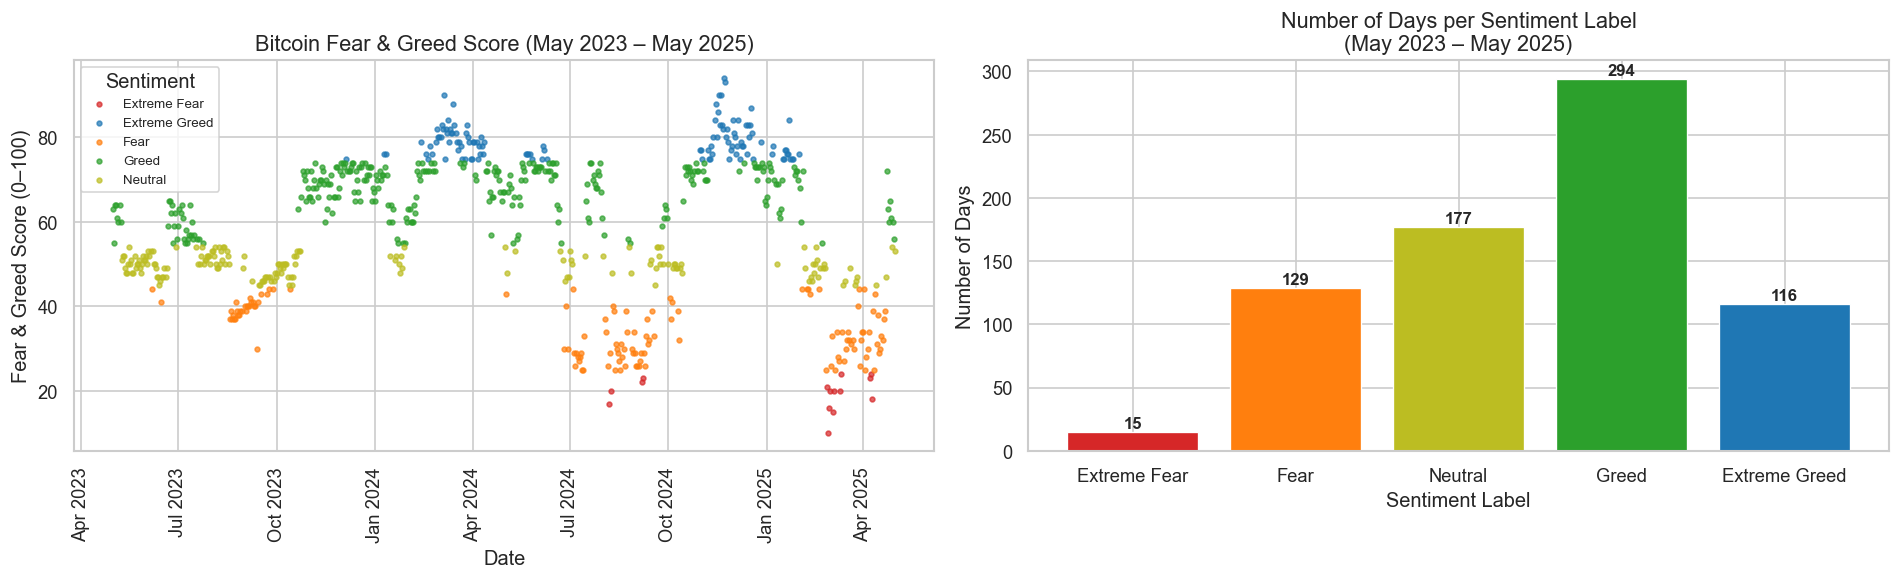

Chart saved as 1_sentiment_distribution.png


In [48]:
# Sentiment Distribution Over Time ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Plot 1: Sentiment score over time ────────────────────────────────
# Filter sentiment_df to match our trading window
sentiment_window = sentiment_df[
    (sentiment_df['date'] >= '2023-05-01') & 
    (sentiment_df['date'] <= '2025-05-01')
].copy()

# Colour-map each label
color_map = {
    'Extreme Fear' : '#d62728',
    'Fear' : '#ff7f0e',
    'Neutral' : '#bcbd22',
    'Greed' : '#2ca02c',
    'Extreme Greed': '#1f77b4'
}

for label, grp in sentiment_window.groupby('fg_label'):
    axes[0].scatter(grp['date'], grp['fg_value'],
                    label=label, color=color_map[label],
                    s=8, alpha=0.7)

axes[0].set_title('Bitcoin Fear & Greed Score (May 2023 – May 2025)', fontsize=13)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Fear & Greed Score (0–100)')
axes[0].legend(title='Sentiment', fontsize=8)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=90)

# ── Plot 2: Count of trading days per sentiment label ────────────────
label_order  = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
label_counts = sentiment_window['fg_label'].value_counts().reindex(label_order)
colors       = [color_map[l] for l in label_order]

axes[1].bar(label_order, label_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Number of Days per Sentiment Label\n(May 2023 – May 2025)', fontsize=13)
axes[1].set_xlabel('Sentiment Label')
axes[1].set_ylabel('Number of Days')
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('1_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 1_sentiment_distribution.png")

**Chart 1: Fear & Greed Score Over Time**

**Observations:**

**1. Three distinct sentiment phases are clearly visible:**
- **May–Sep 2023:** Mixed Fear/Neutral zone (scores 35–60).
- **Oct 2023–Mar 2024:** Strong Greed/Extreme Greed surge (scores 65–90).
- **Apr–Sep 2024:** Sharp drop back into Fear territory.
- **Oct 2024–Jan 2025:** Another powerful Extreme Greed surge.
- **Feb–May 2025:** Return to Fear/Neutral.

**2. Sentiment is cyclical and clusters in phases** — Fear and Greed don't alternate day by day, they persist in regimes for weeks or months. This is critical because it means our trader behavior differences between Fear and Greed days reflect genuine sustained market conditions, not random noise.

**Chart 2: Days per Sentiment Label**

| Label | Days |
|:--|:--|
| Extreme Fear | 15 |
| Fear | 129 |
| Neutral | 177 |
| Greed | 294 |
| Extreme Greed | 116 |

**Observations:**

**3. Greed dominated this 2-year window (294 days = 40.6% of the period)**. This was largely a bull market cycle, which is historically accurate for 2023–2025.

**4. Extreme Fear is severely underrepresented (only 15 days = 2.1%)**. This confirms our earlier decision to **combine Fear + Extreme Fear** into one group and **Greed + Extreme Greed** into another for any statistical comparison. Using Extreme Fear alone (15 days) would produce unreliable results.

**5. Going forward, we will use this 3-way grouping:**

```python
Sentiment grouping strategy:
Fear    → Extreme Fear + Fear        (144 days)
Neutral → Neutral                    (177 days)  
Greed   → Greed + Extreme Greed      (410 days)
```

### PnL Distribution Across Traders

Now we will see how profits and losses are distributed across all trader-days. This tells us whether we're dealing with a few big winners, many small winners, or a more even distribution, which directly shapes how we interpret every subsequent analysis.

In [49]:
# ── PnL Distribution Across Traders ──────────────────────────────

# First, let's add the 3-way sentiment grouping we decided earlier
sentiment_3way = {
    'Extreme Fear' : 'Fear',
    'Fear'         : 'Fear',
    'Neutral'      : 'Neutral',
    'Greed'        : 'Greed',
    'Extreme Greed': 'Greed'
}
daily_trader['sentiment_group'] = daily_trader['fg_label'].map(sentiment_3way)
daily_market['sentiment_group'] = daily_market['fg_label'].map(sentiment_3way)

# ── Removing NaN PnL rows for this plot (open trades, no PnL yet) ───────
pnl_valid = daily_trader.dropna(subset=['total_pnl']).copy()

# ── Clipping extreme outliers for visualisation only (not removing data) ──
pnl_clipped = pnl_valid['total_pnl'].clip(-5000, 15000)

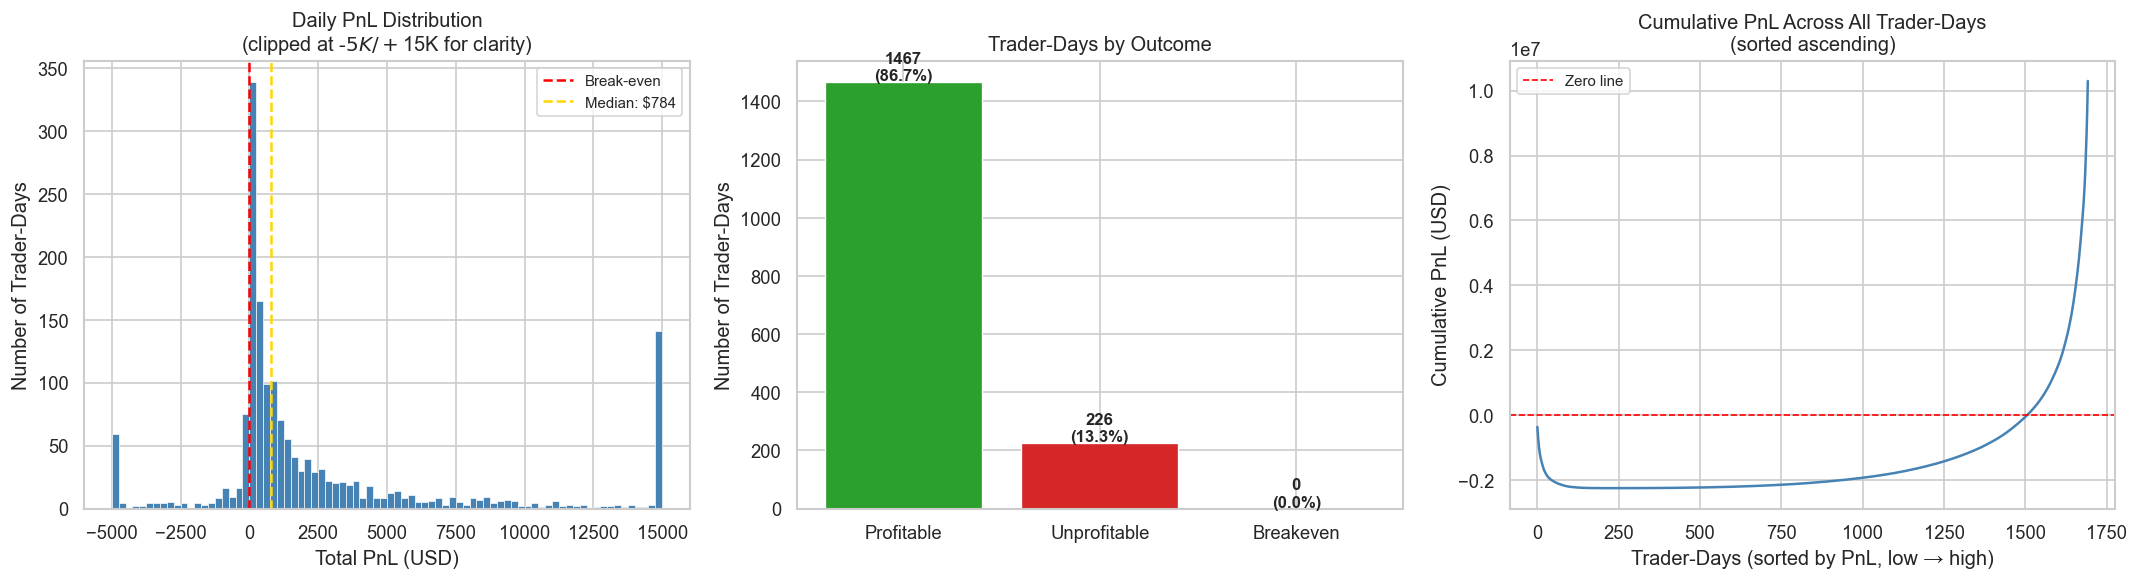

Chart saved as 2_pnl_distribution.png


In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Raw PnL histogram ─────────────────────────────────────────
axes[0].hist(pnl_clipped, bins=80, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
axes[0].axvline(pnl_valid['total_pnl'].median(), color='gold', 
                linestyle='--', linewidth=1.5, 
                label=f"Median: ${pnl_valid['total_pnl'].median():.0f}")
axes[0].set_title('Daily PnL Distribution\n(clipped at -$5K / +$15K for clarity)', fontsize=12)
axes[0].set_xlabel('Total PnL (USD)')
axes[0].set_ylabel('Number of Trader-Days')
axes[0].legend(fontsize=9)

# ── Plot 2: % of profitable vs unprofitable trader-days ──────────────
profitable   = (pnl_valid['total_pnl'] > 0).sum()
unprofitable = (pnl_valid['total_pnl'] < 0).sum()
breakeven    = (pnl_valid['total_pnl'] == 0).sum()

labels = ['Profitable', 'Unprofitable', 'Breakeven']
values = [profitable, unprofitable, breakeven]
colors = ['#2ca02c', '#d62728', '#bcbd22']
axes[1].bar(labels, values, color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Trader-Days by Outcome', fontsize=12)
axes[1].set_ylabel('Number of Trader-Days')
for i, v in enumerate(values):
    axes[1].text(i, v + 5, f'{v}\n({v/len(pnl_valid)*100:.1f}%)', 
                 ha='center', fontsize=10, fontweight='bold')

# ── Plot 3: Cumulative PnL distribution (how concentrated are gains?) ─
sorted_pnl = pnl_valid['total_pnl'].sort_values().reset_index(drop=True)
cumulative  = sorted_pnl.cumsum()
axes[2].plot(range(len(cumulative)), cumulative.values, color='steelblue', linewidth=1.5)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1, label='Zero line')
axes[2].set_title('Cumulative PnL Across All Trader-Days\n(sorted ascending)', fontsize=12)
axes[2].set_xlabel('Trader-Days (sorted by PnL, low → high)')
axes[2].set_ylabel('Cumulative PnL (USD)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('2_pnl_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 2_pnl_distribution.png")

In [51]:
# ── Summary stats ─────────────────────────────────────────────────────
print("\nPnL Summary (trader-day level):")
print(f"  Total trader-days with PnL data : {len(pnl_valid):,}")
print(f"  Profitable days                 : {profitable:,} ({profitable/len(pnl_valid)*100:.1f}%)")
print(f"  Unprofitable days               : {unprofitable:,} ({unprofitable/len(pnl_valid)*100:.1f}%)")
print(f"  Median daily PnL                : ${pnl_valid['total_pnl'].median():,.2f}")
print(f"  Mean daily PnL                  : ${pnl_valid['total_pnl'].mean():,.2f}")
print(f"  Total PnL (all traders, all days): ${pnl_valid['total_pnl'].sum():,.2f}")


PnL Summary (trader-day level):
  Total trader-days with PnL data : 1,693
  Profitable days                 : 1,467 (86.7%)
  Unprofitable days               : 226 (13.3%)
  Median daily PnL                : $783.83
  Mean daily PnL                  : $6,082.08
  Total PnL (all traders, all days): $10,296,958.94


**Chart 1: Daily PnL Distribution (Histogram)**

**Observations:**

**1. Extreme right skew confirmed.** The vast majority of trader-days cluster tightly between -1K and +2K, but the distribution has a very long right tail stretching far beyond $15K (those are clipped). The median ($784) sits very close to zero — the typical trading day is a small win.

**2. The large bar at the far right (~15K+) represents all the extreme outlier days** that got clipped. There are ~140 such trader-days with PnL above 15K. These are a small count but contribute massively to total PnL.

**3. There are notable losses on the left side too** — a cluster around -$4K to -$5K range, suggesting when traders lose, they lose significantly relative to their typical wins. Classic asymmetric payoff pattern.

**Chart 2: Trader-Days by Outcome**

| Outcome | Count | % |
|:--|:--|:--|
| Profitable | 1,467 | 86.7% |
| Unprofitable | 226 | 13.3% |
| Breakeven | 0 | 0.0% |

**4. The honest trader-day win rate is 86.7%** which is still high, but now we understand why. The granularity bias from row-level analysis (83.2%) is actually slightly lower than the trader-day level (86.7%), which is counterintuitive. This tells us that on days where traders close positions, they genuinely close more profitable days than unprofitable ones — but those unprofitable days tend to be much larger in magnitude.

**5. Zero breakeven days** — in leveraged crypto trading, landing exactly at zero is virtually impossible. Every day has some net positive or negative outcome.

**Chart 3: Cumulative PnL**

**6. The cumulative curve tells the most important story of the entire dataset:**
- The curve **drops sharply into negative territory** for the first ~300 trader-days (the worst performers)
- It stays **flat near zero** for the middle ~1,100 trader-days (many small winners)
- Then **explodes upward** in the last ~300 trader-days (the big winners)

**7. This is a classic "Power Law" distribution**, a tiny minority of trader-days generate almost all the profits. The top ~18% of trader-days are responsible for essentially all of the $10.3M total PnL. The bottom 13% of days destroyed significant capital.

**8. Total PnL across all traders and all days: 10,296,958**, the collective profit pool of this entire trader cohort over 2 years.

**Key Takeaway:**   
This dataset is dominated by a small number of extremely profitable trader-days. Mean (6,082) is 7.7x the median (784). The 86.7% win rate is real at the trader-day level but misleading because the 13.3% losing days are disproportionately large in magnitude.

### Trade Activity Over Time

Next, we will see how trading volume, trader count, and market participation evolved across our 2-year window, and whether activity levels correlate with sentiment periods.

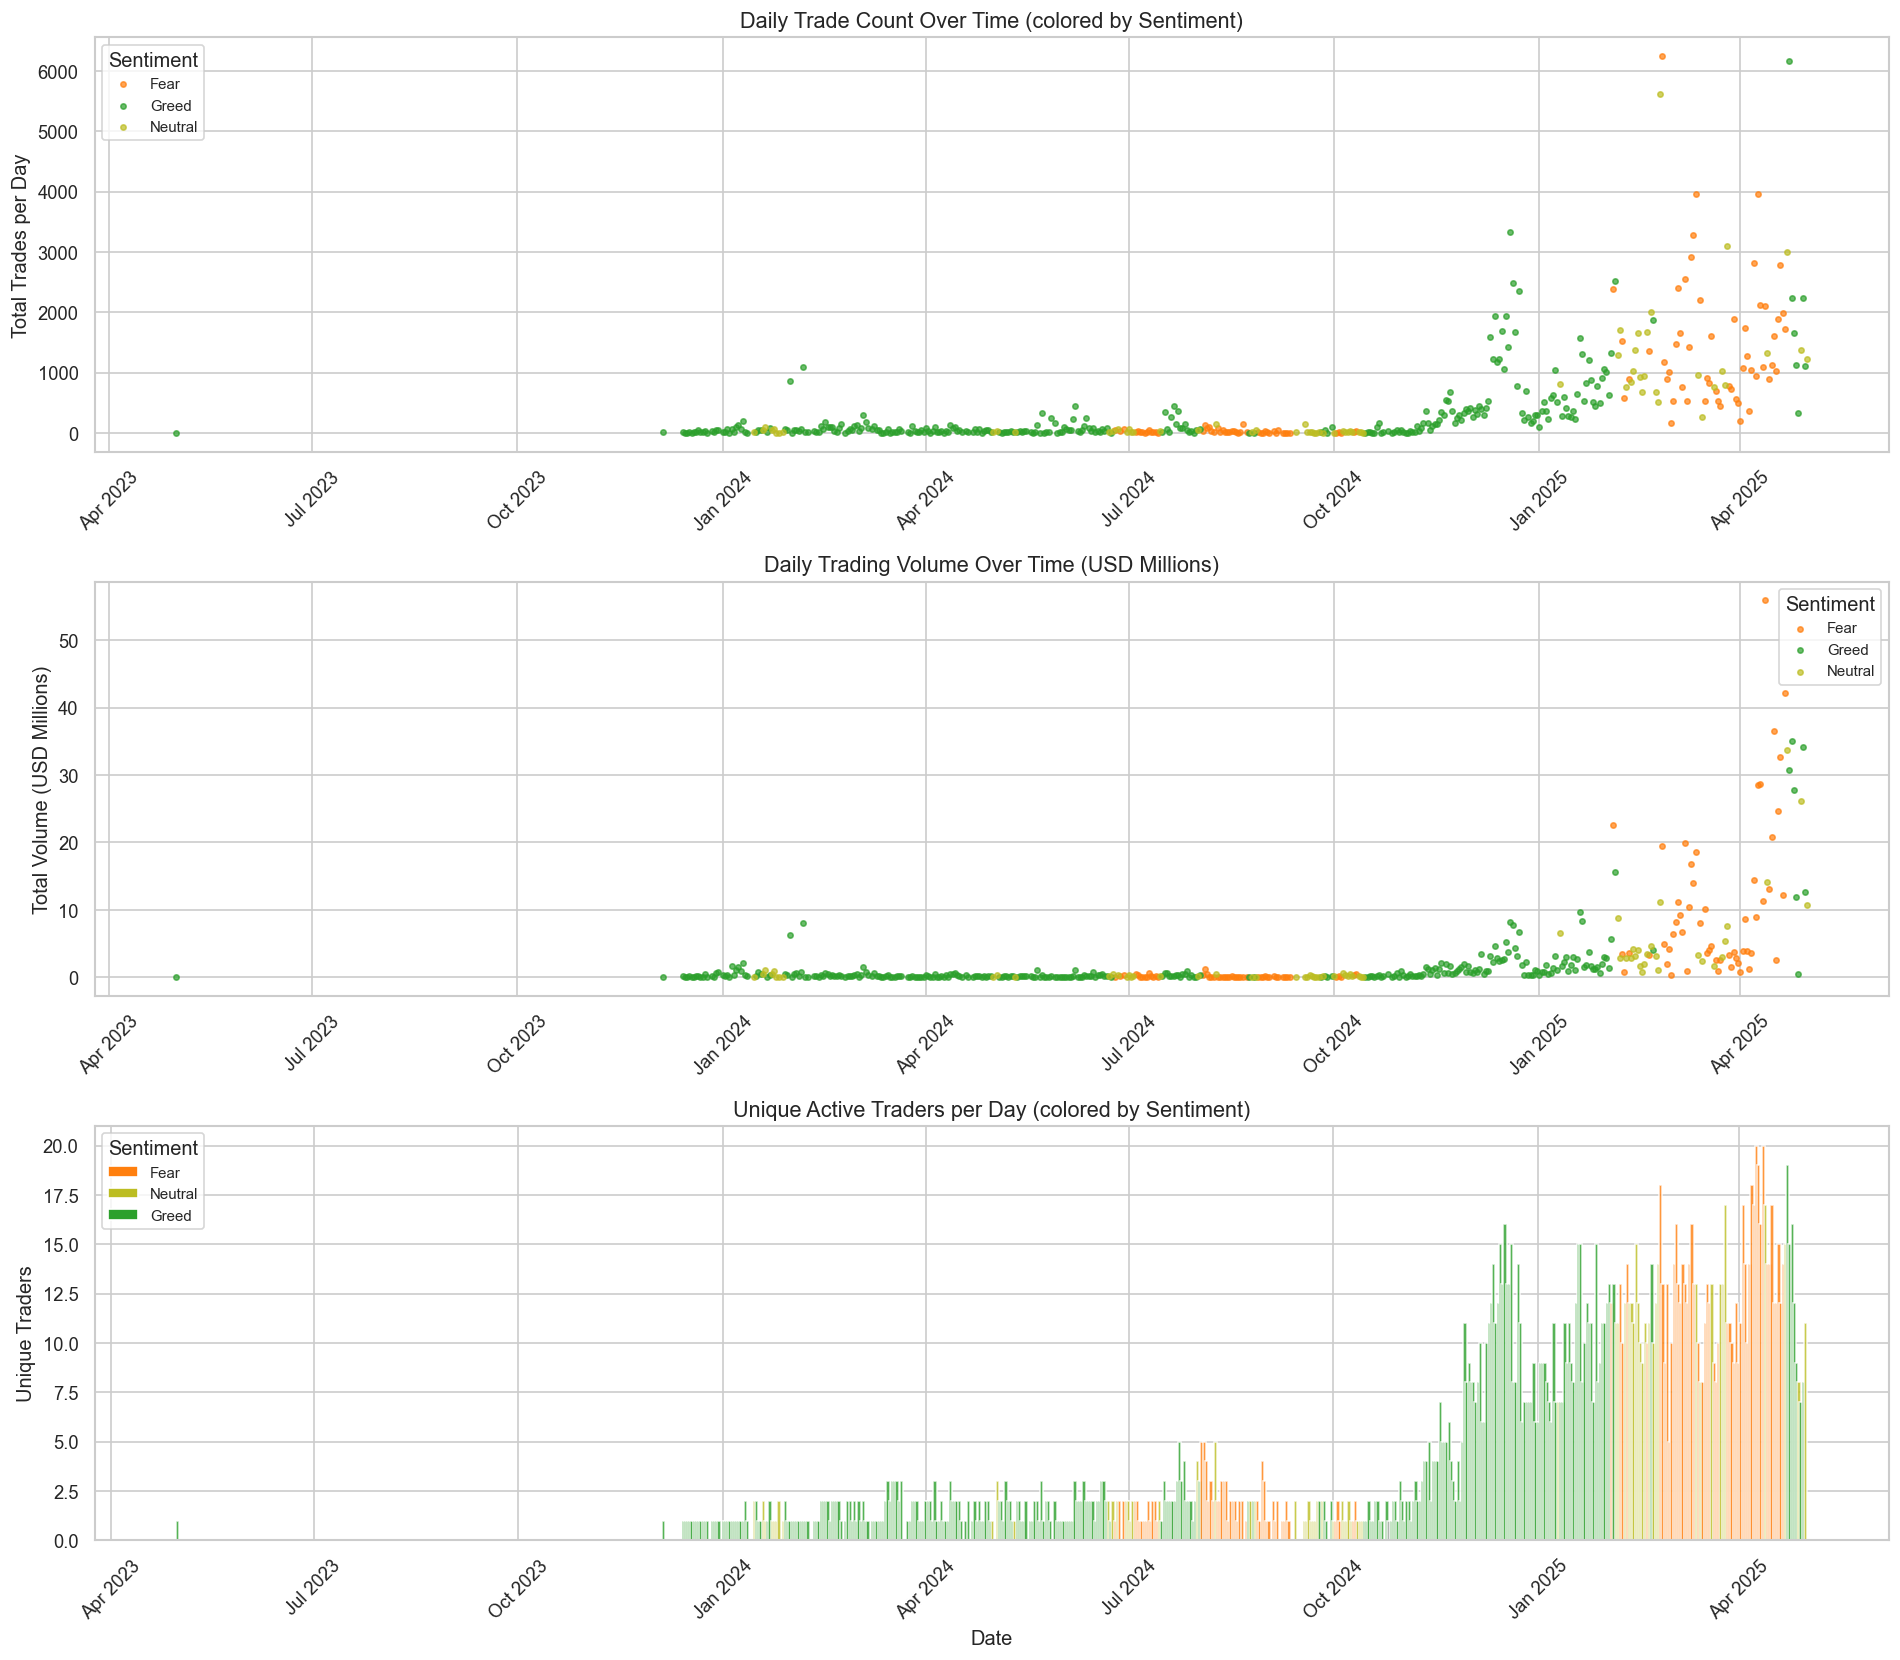

Chart saved as 3_trade_activity_over_time.png


In [52]:
# ── Trade Activity Over Time ─────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# ── Color map for sentiment groups ───────────────────────────────────
sg_colors = {'Fear': '#ff7f0e', 'Neutral': '#bcbd22', 'Greed': '#2ca02c'}

# ── Plot 1: Daily trade count over time, colored by sentiment ─────────
for sg, grp in daily_market.groupby('sentiment_group'):
    axes[0].scatter(grp['date'], grp['total_trades'],
                    color=sg_colors.get(sg, 'grey'),
                    label=sg, s=10, alpha=0.7)

axes[0].set_title('Daily Trade Count Over Time (colored by Sentiment)', fontsize=13)
axes[0].set_ylabel('Total Trades per Day')
axes[0].legend(title='Sentiment', fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# ── Plot 2: Daily volume over time ────────────────────────────────────
for sg, grp in daily_market.groupby('sentiment_group'):
    axes[1].scatter(grp['date'], grp['total_volume'] / 1e6,
                    color=sg_colors.get(sg, 'grey'),
                    label=sg, s=10, alpha=0.7)

axes[1].set_title('Daily Trading Volume Over Time (USD Millions)', fontsize=13)
axes[1].set_ylabel('Total Volume (USD Millions)')
axes[1].legend(title='Sentiment', fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

# ── Plot 3: Unique traders per day over time (fixed) ──────────────────
bar_colors = daily_market['sentiment_group'].map(sg_colors).fillna('#aaaaaa')

axes[2].bar(daily_market['date'], daily_market['unique_traders'],
            color=bar_colors,
            alpha=0.8, width=1.5)

axes[2].set_title('Unique Active Traders per Day (colored by Sentiment)', fontsize=13)
axes[2].set_ylabel('Unique Traders')
axes[2].set_xlabel('Date')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

# ── Manual legend for Plot 3 ──────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=sg_colors[sg], label=sg) for sg in sg_colors]
axes[2].legend(handles=legend_elements, title='Sentiment', fontsize=9)

plt.tight_layout()
plt.savefig('3_trade_activity_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 3_trade_activity_over_time.png")

In [53]:
# ── Summary stats by sentiment group ─────────────────────────────────
print("\nActivity Summary by Sentiment Group:")
print(daily_market.groupby('sentiment_group')[
    ['total_trades', 'total_volume', 'unique_traders']
].median().round(2))


Activity Summary by Sentiment Group:
                 total_trades  total_volume  unique_traders
sentiment_group                                            
Fear                 192.0000   839734.9700          8.0000
Greed                 63.0000   286377.2000          2.0000
Neutral               50.0000   403002.8000          2.0000


**Chart Observations:**

**1. The dataset has a dramatic growth pattern — almost no activity before Dec 2023.** The first 7 months (May–Dec 2023) are nearly empty. Real trading activity only begins in earnest from Jan 2024, and explodes from Oct 2024 onwards. This is not a data quality issue — it reflects genuine platform growth on Hyperliquid.

**2. The high-activity period (Oct 2024–May 2025) is dominated by a MIX of Fear and Greed dots**. Both colors appear densely in the top right, meaning extreme activity occurs under both sentiment conditions.

**3. The highest single-day spikes (~6,000 trades, ~$50M volume) appear in the Fear zone (orange)** visible in early 2025. These are likely panic/volatility-driven trading events.

**Summary Table — The Most Counterintuitive Finding So Far**

| Sentiment | Median Trades/Day | Median Volume/Day | Median Traders/Day |
|:--|:--|:--|:--|
| **Fear** | **192** | **839,734** | **8** |
| Neutral | 50 | 403,002 | 2 |
| **Greed** | **63** | **286,377** | **2** |

**4. Fear days have 3x more trades and 3x more volume than Greed days.** This is completely counterintuitive, conventional wisdom says Greed drives more trading. But before drawing conclusions, we must identify the **critical confound** hiding in this data.

**5. This is a TIME CONFOUND, not a sentiment effect.** Here is what actually happened:

- **Jan 2024–Sep 2024:** Low activity period → mostly Greed sentiment (bull market)
- **Oct 2024–May 2025:** High activity period → mix of Fear AND Greed, but Fear days happen to cluster in the highest-activity months

In other words, **the dataset grew over time**, and the Fear days just happened to coincide with the period when more traders had joined the platform. The apparent Fear → more trading relationship is driven by time, not sentiment.

**6. This means we cannot use raw activity levels to compare Fear vs Greed.** We need to control for this time effect in our Part B behavioral analysis. We will do this by looking at **relative changes** and **per-trader metrics** rather than absolute market-wide counts.

**Key Takeaway:**   
The time confound is the most important methodological finding of the EDA. Every market-level comparison between Fear and Greed must account for the fact that the dataset grows significantly over time and the growth period coincides unevenly with sentiment labels. **Per-trader metrics in `daily_trader` are more reliable than market-level metrics in `daily_market` for sentiment comparisons.**

### Fear vs Greed: PnL & Performance Comparison

This directly answers Part B Question 1 — *"Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?"*

We will look at three performance dimensions:
- **Total PnL** — how much money was made/lost
- **Win rate** — what proportion of trader-days were profitable
- **Drawdown proxy** — how bad were the losing days

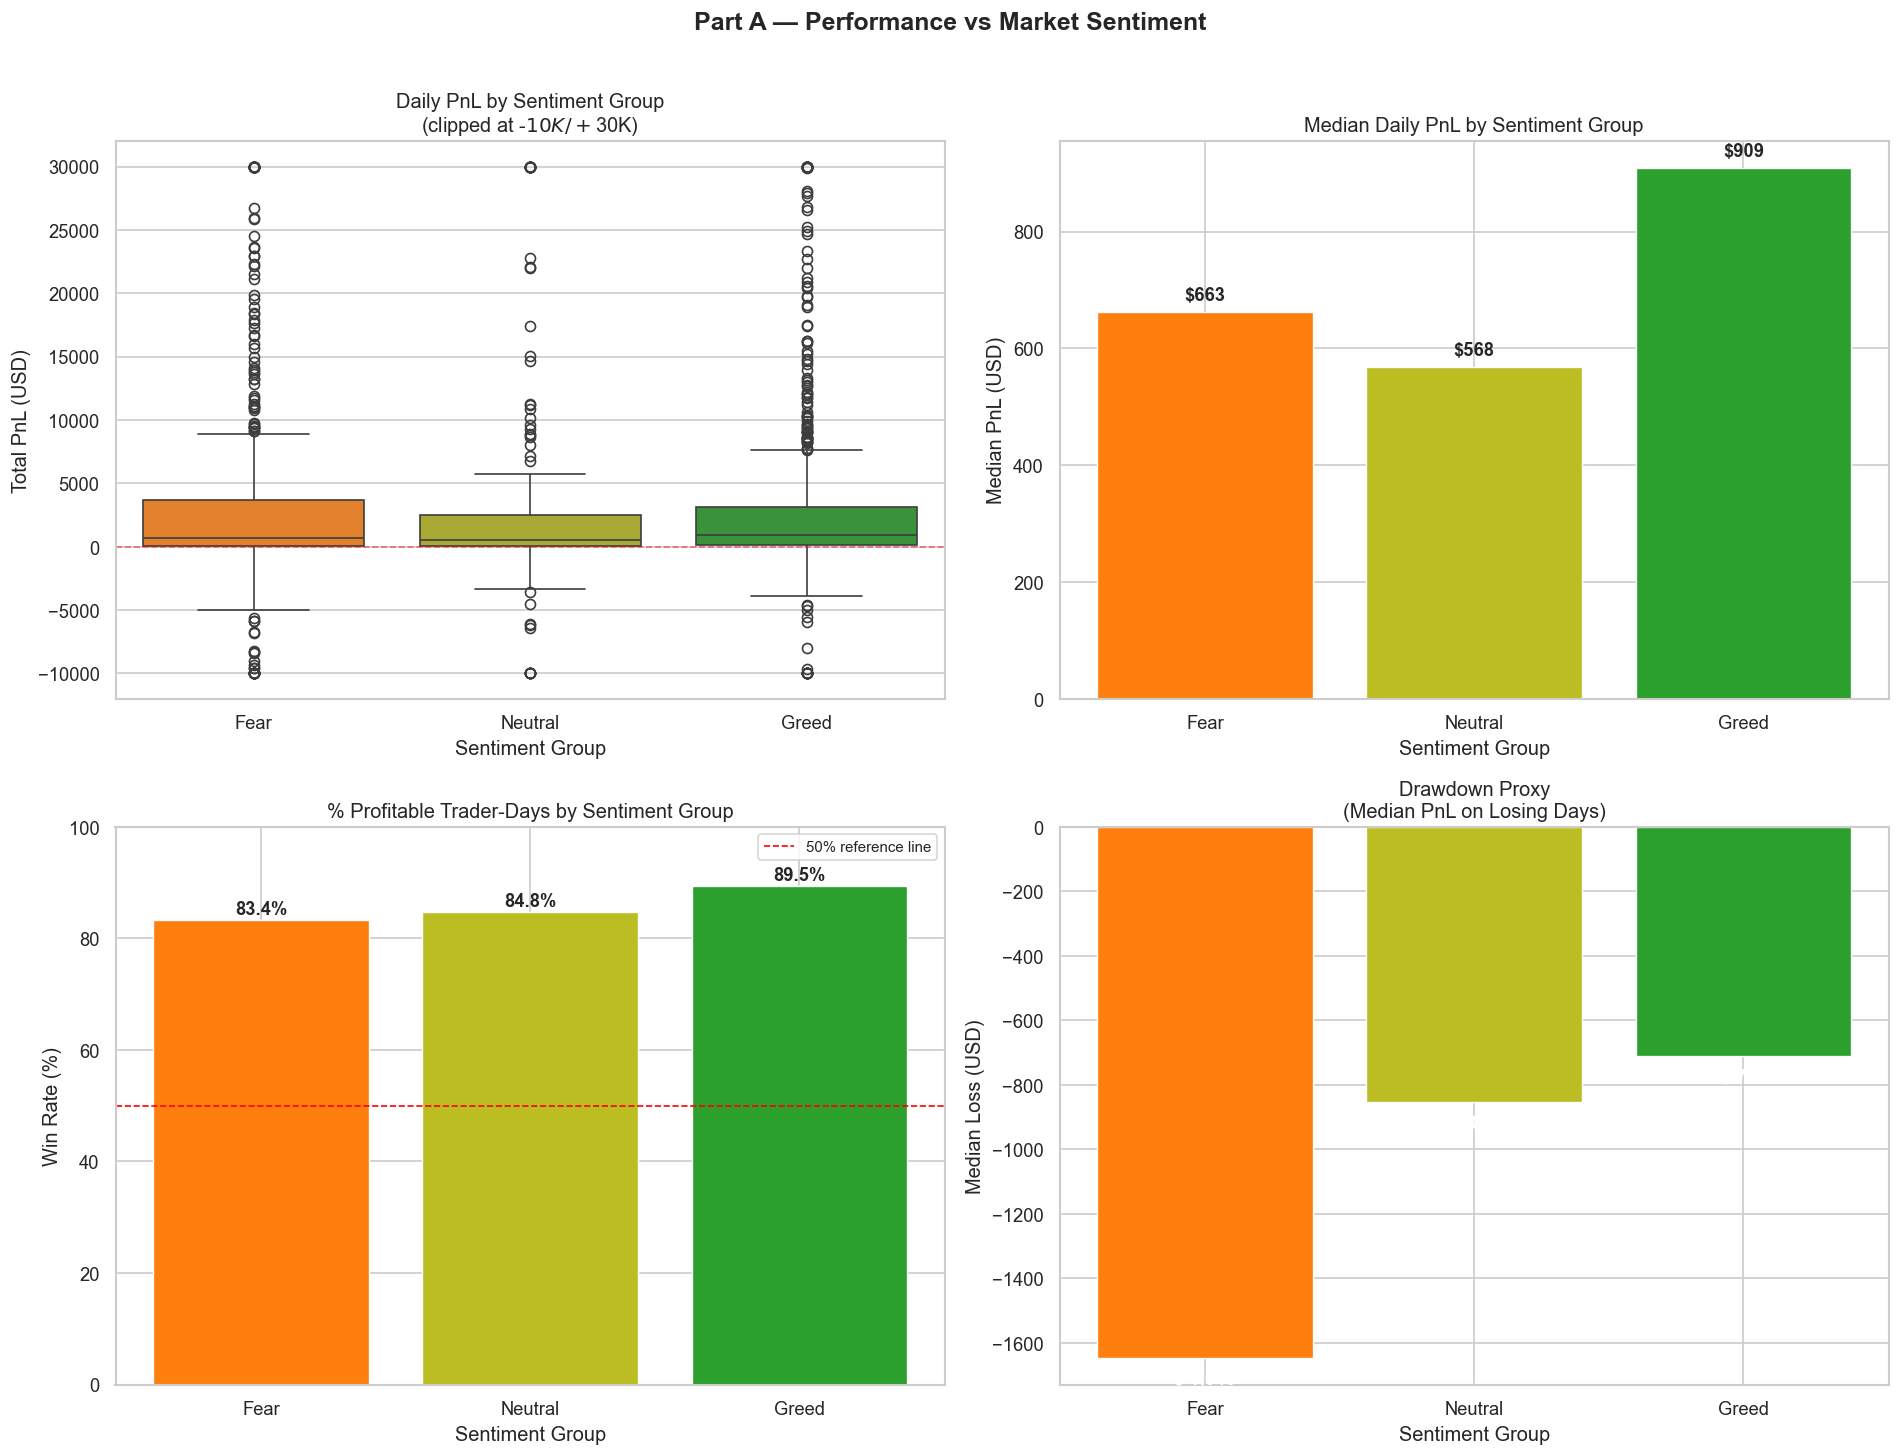

Chart saved as 4_performance_vs_sentiment.png


In [54]:
# ── Fear vs Greed: PnL & Performance Comparison ──────────────────

perf = daily_trader.dropna(subset=['total_pnl', 'sentiment_group']).copy()
perf['is_profitable_day'] = (perf['total_pnl'] > 0).astype(int)
perf['total_pnl_clipped'] = perf['total_pnl'].clip(-10000, 30000)

sg_order       = ['Fear', 'Neutral', 'Greed']
sg_colors_list = ['#ff7f0e', '#bcbd22', '#2ca02c']
sg_palette     = {'Fear': '#ff7f0e', 'Neutral': '#bcbd22', 'Greed': '#2ca02c'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Plot 1: Box plot of daily PnL by sentiment group ─────────────────
sns.boxplot(
    data=perf,
    x='sentiment_group', y='total_pnl_clipped',
    hue='sentiment_group',
    order=sg_order, palette=sg_palette,
    ax=axes[0, 0]
)


axes[0, 0].set_title('Daily PnL by Sentiment Group\n(clipped at -$10K / +$30K)', fontsize=12)
axes[0, 0].set_xlabel('Sentiment Group')
axes[0, 0].set_ylabel('Total PnL (USD)')
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# ── Plot 2: Median PnL per sentiment group ────────────────────────────
median_pnl = perf.groupby('sentiment_group')['total_pnl'].median().reindex(sg_order)
axes[0, 1].bar(sg_order, median_pnl.values, color=sg_colors_list,
               edgecolor='white', linewidth=0.8)
axes[0, 1].set_title('Median Daily PnL by Sentiment Group', fontsize=12)
axes[0, 1].set_xlabel('Sentiment Group')
axes[0, 1].set_ylabel('Median PnL (USD)')
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1)
for i, v in enumerate(median_pnl.values):
    axes[0, 1].text(i, v + 20, f'${v:,.0f}', ha='center',
                    fontsize=11, fontweight='bold')

# ── Plot 3: Win rate by sentiment ─────────────────────────────────────
win_rate_by_sg = perf.groupby('sentiment_group')['is_profitable_day'].mean() * 100
win_rate_by_sg = win_rate_by_sg.reindex(sg_order)

axes[1, 0].bar(sg_order, win_rate_by_sg.values, color=sg_colors_list,
               edgecolor='white', linewidth=0.8)
axes[1, 0].set_title('% Profitable Trader-Days by Sentiment Group', fontsize=12)
axes[1, 0].set_xlabel('Sentiment Group')
axes[1, 0].set_ylabel('Win Rate (%)')
axes[1, 0].set_ylim(0, 100)
axes[1, 0].axhline(50, color='red', linestyle='--', linewidth=1,
                    label='50% reference line')
axes[1, 0].legend(fontsize=9)
for i, v in enumerate(win_rate_by_sg.values):
    axes[1, 0].text(i, v + 1, f'{v:.1f}%', ha='center',
                    fontsize=11, fontweight='bold')

# ── Plot 4: Drawdown proxy ────────────────────────────────────────────
losing_days = perf[perf['total_pnl'] < 0]
drawdown = losing_days.groupby('sentiment_group')['total_pnl'].median().reindex(sg_order)

axes[1, 1].bar(sg_order, drawdown.values, color=sg_colors_list,
               edgecolor='white', linewidth=0.8)
axes[1, 1].set_title('Drawdown Proxy\n(Median PnL on Losing Days)', fontsize=12)
axes[1, 1].set_xlabel('Sentiment Group')
axes[1, 1].set_ylabel('Median Loss (USD)')
for i, v in enumerate(drawdown.values):
    axes[1, 1].text(i, v - 80, f'${v:,.0f}', ha='center',
                    fontsize=11, fontweight='bold', color='white')

plt.suptitle('Part A — Performance vs Market Sentiment',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('4_performance_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 4_performance_vs_sentiment.png")

In [55]:
# ── Summary statistics table ──────────────────────────────────────────
print("PERFORMANCE SUMMARY BY SENTIMENT GROUP")
summary = perf.groupby('sentiment_group').agg(
    trader_days   = ('total_pnl',           'count'),
    median_pnl    = ('total_pnl',           'median'),
    mean_pnl      = ('total_pnl',           'mean'),
    win_rate_pct  = ('is_profitable_day',   'mean'),
    total_pnl_sum = ('total_pnl',           'sum'),
).reindex(sg_order)

summary['win_rate_pct']  = (summary['win_rate_pct'] * 100).round(1)
summary['median_pnl']    = summary['median_pnl'].round(2)
summary['mean_pnl']      = summary['mean_pnl'].round(2)
summary['total_pnl_sum'] = summary['total_pnl_sum'].round(2)
summary

PERFORMANCE SUMMARY BY SENTIMENT GROUP


,trader_days,median_pnl,mean_pnl,win_rate_pct,total_pnl_sum
sentiment_group,,,,,
Fear,572,662.9600,7161.3000,83.4000,4096265.6900
Neutral,276,567.8000,4684.5000,84.8000,1292920.6800
Greed,844,909.4600,5764.5700,89.5000,4865300.5800


**Chart-by-Chart Analysis:**

**Plot 1 — Boxplot (PnL Distribution Shape):**

**1. Fear has the widest box of all three groups.** The interquartile range (IQR) of Fear days stretches much further than Greed days, meaning PnL outcomes are far more dispersed under Fear. Some traders make enormous gains on Fear days, others suffer severe losses. Fear creates high-variance outcomes.

**2. Greed days have a tighter, more consistent distribution.** The box is narrower and sits closer to zero. Greed days produce more predictable, moderate positive outcomes.

**3. All three groups have extreme outliers above the clip line**, very large winning days exist under every sentiment condition, but they are most numerous under Fear and Greed.


**Plot 2 — Median PnL:**

**4. Greed days produce the highest median PnL (909) — 37% higher than Fear days ($663).** This is the cleanest, most direct answer to Part A Question 1. On a typical trading day, a Greed environment produces meaningfully better returns.

**5. The Fear vs Neutral difference is modest ($663 vs $568)**. Fear is actually slightly better than Neutral, suggesting Fear alone doesn't necessarily hurt performance.


**Plot 3 — Win Rate:**

**6. Win rate increases monotonically: Fear (83.4%) → Neutral (84.8%) → Greed (89.5%).** Each step up in sentiment corresponds to a higher probability of having a profitable day. Greed days give traders a 6.1 percentage point win rate advantage over Fear days.

**7. All groups are well above 50%**. traders in this cohort are profitable under every sentiment condition, but significantly more so during Greed.


**Plot 4 — Drawdown Proxy:**

**8. The most striking finding: Fear days produce the deepest losses (-1,622) when things go wrong, more than double the Greed drawdown (-$648).** This means:
- On Greed days, when you lose, you lose ~$648
- On Fear days, when you lose, you lose ~$1,622 — **2.5x worse**

**9. Neutral sits in the middle (-$857)**, consistent with it being a transitional state between Fear and Greed.

**Answer to Part B Question 1**

> *"Does performance differ between Fear vs Greed days?"*

**Yes, clearly and consistently across all three metrics:**

| Metric | Winner | Magnitude |
|:--|:--|:--|
| Median PnL | Greed (+909 vs +663) | +37% better |
| Win Rate | Greed (89.5% vs 83.4%) | +6.1pp better |
| Drawdown (loss days) | Greed (-648 vs -1,622) | 2.5x less severe |

**The core finding: Greed days are better on all three dimensions — higher profits, more winning days, and shallower losses when things go wrong. Fear days are characterized by high variance — the upside exists but so does the risk of catastrophic loss.**

**One important caveat to note:** Fear days have 572 trader-days vs Greed's 844; the time confound from 4.3 is still present. The Fear days are concentrated in the more recent, higher-activity period. However since we are using **per-trader-day medians** (not market totals), this effect is substantially mitigated.

### Fear vs Greed: Behavioral Comparison

This directly answers Part B Question 2 — *"Do traders change behavior based on sentiment?"* 

We will look at four behavioral dimensions:
- **Trade frequency** — do traders trade more or less under Fear?
- **Position size** — do they deploy more or less capital?
- **Long/Short bias** — do they change directional stance?
- **Fee spend** — a proxy for overall aggression

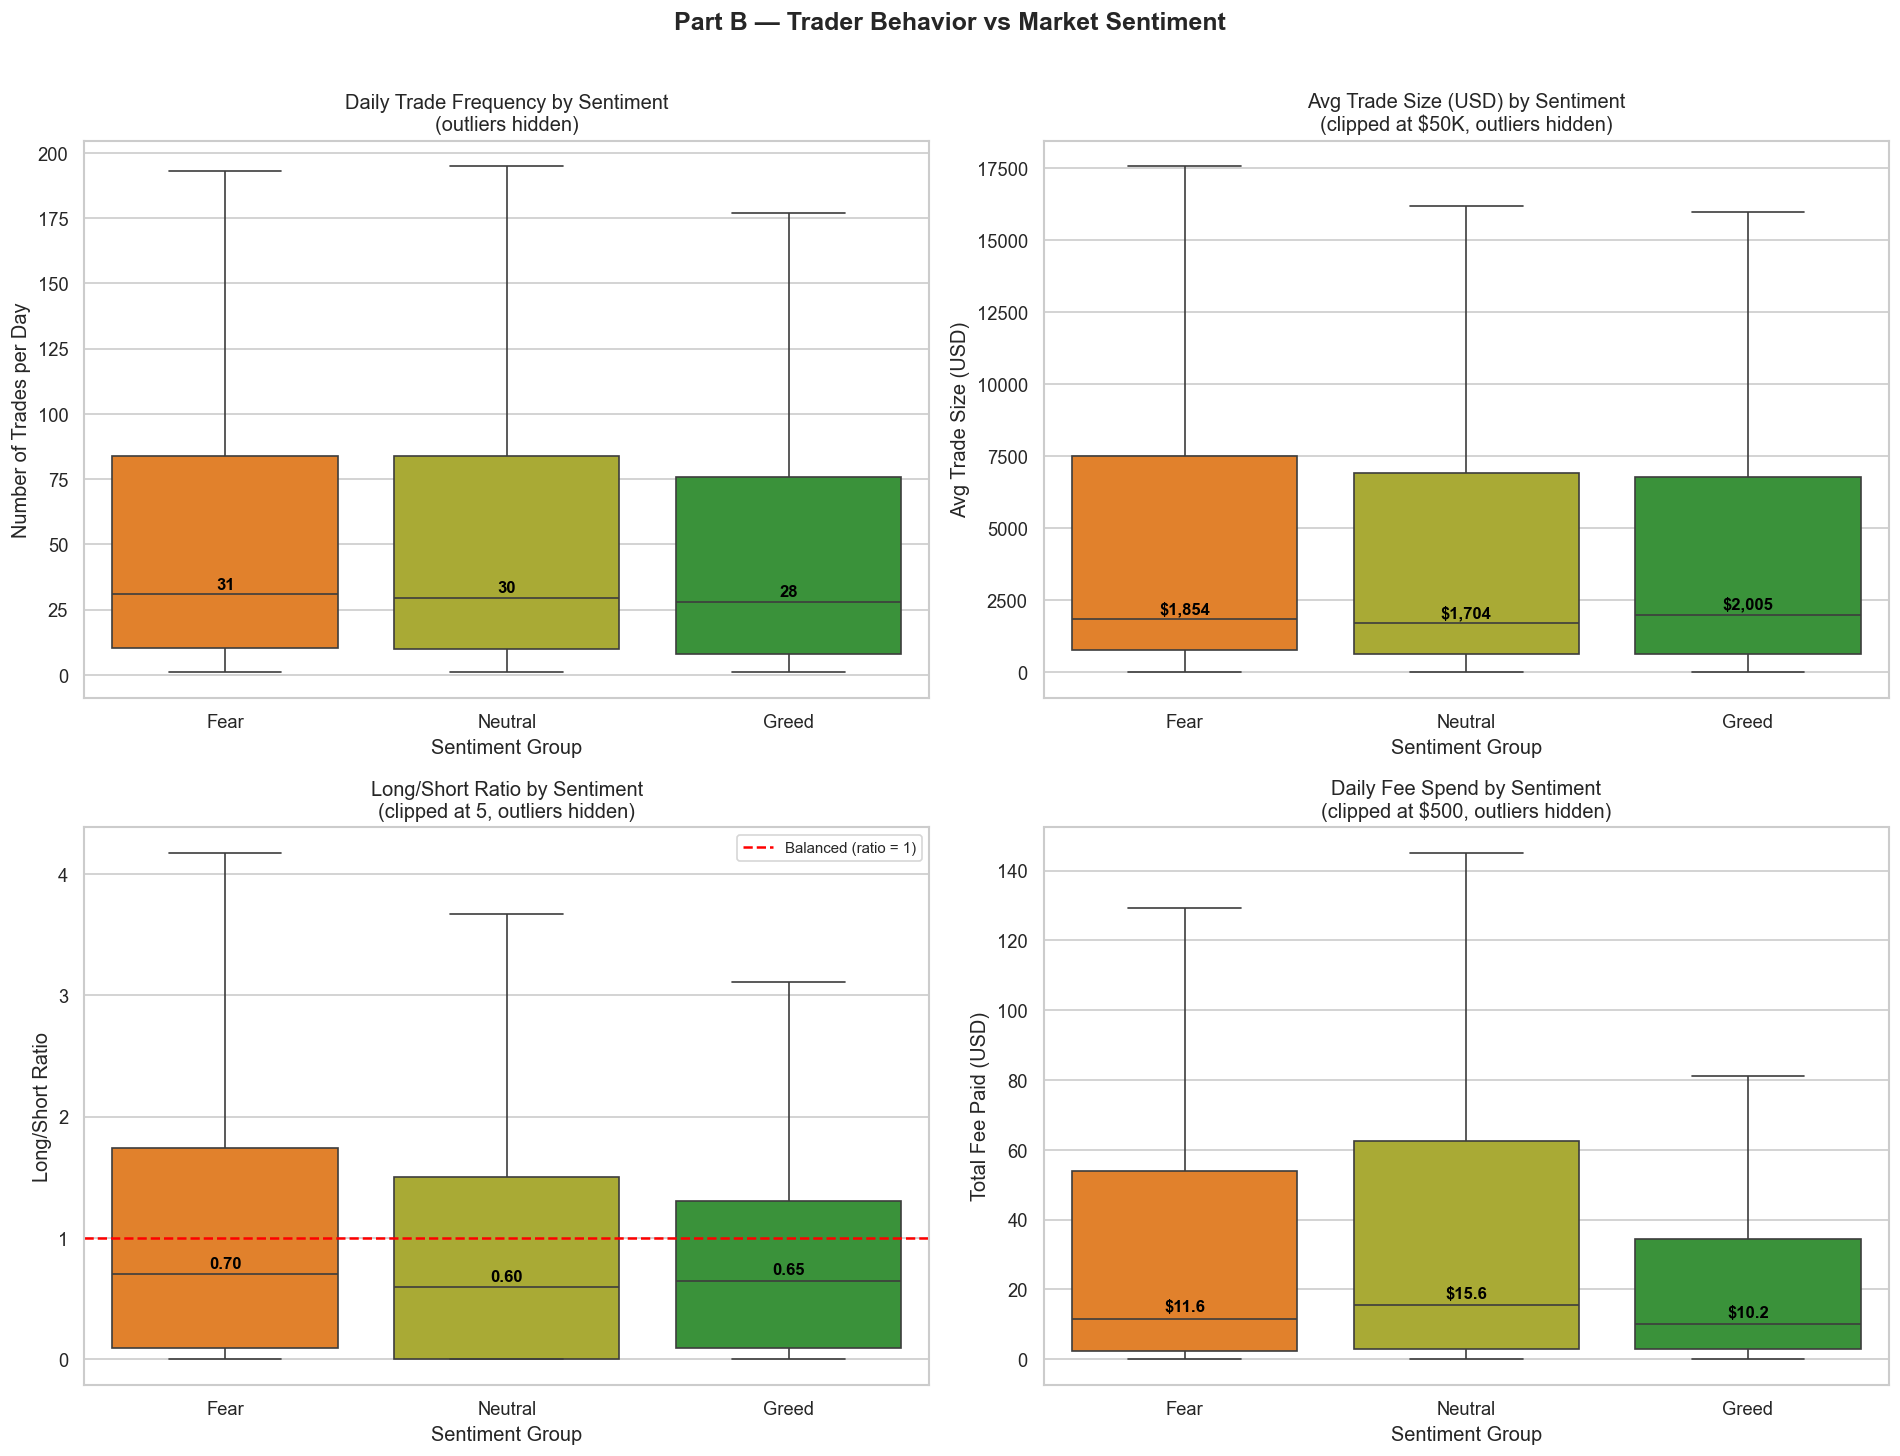

Chart saved as 5_behavior_vs_sentiment.png


In [56]:
# ── Fear vs Greed: Behavioral Comparison ─────────────────────────

behav = daily_trader.dropna(subset=['sentiment_group']).copy()

sg_order       = ['Fear', 'Neutral', 'Greed']
sg_colors_list = ['#ff7f0e', '#bcbd22', '#2ca02c']
sg_palette     = {'Fear': '#ff7f0e', 'Neutral': '#bcbd22', 'Greed': '#2ca02c'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Plot 1: Trade frequency (n_trades) by sentiment ───────────────────
sns.boxplot(
    data=behav,
    x='sentiment_group', y='n_trades',
    hue='sentiment_group',
    order=sg_order, palette=sg_palette,
    ax=axes[0, 0],
    showfliers=False       
)
axes[0, 0].set_title('Daily Trade Frequency by Sentiment\n(outliers hidden)', fontsize=12)
axes[0, 0].set_xlabel('Sentiment Group')
axes[0, 0].set_ylabel('Number of Trades per Day')

# overlay median labels
for i, sg in enumerate(sg_order):
    med = behav[behav['sentiment_group'] == sg]['n_trades'].median()
    axes[0, 0].text(i, med + 2, f'{med:.0f}', ha='center',
                    fontsize=10, fontweight='bold', color='black')

# ── Plot 2: Average position size (avg_size_usd) by sentiment ─────────
behav['avg_size_clipped'] = behav['avg_size_usd'].clip(0, 50000)

sns.boxplot(
    data=behav,
    x='sentiment_group', y='avg_size_clipped',
    hue='sentiment_group',
    order=sg_order, palette=sg_palette,
    ax=axes[0, 1],
    showfliers=False
)
axes[0, 1].set_title('Avg Trade Size (USD) by Sentiment\n(clipped at $50K, outliers hidden)', fontsize=12)
axes[0, 1].set_xlabel('Sentiment Group')
axes[0, 1].set_ylabel('Avg Trade Size (USD)')

for i, sg in enumerate(sg_order):
    med = behav[behav['sentiment_group'] == sg]['avg_size_usd'].median()
    axes[0, 1].text(i, med + 200, f'${med:,.0f}', ha='center',
                    fontsize=10, fontweight='bold', color='black')

# ── Plot 3: Long/Short ratio by sentiment ─────────────────────────────
ls_data = behav.dropna(subset=['ls_ratio']).copy()
ls_data['ls_ratio_clipped'] = ls_data['ls_ratio'].clip(0, 5)

sns.boxplot(
    data=ls_data,
    x='sentiment_group', y='ls_ratio_clipped',
    hue='sentiment_group',
    order=sg_order, palette=sg_palette,
    ax=axes[1, 0],
    showfliers=False
)
axes[1, 0].set_title('Long/Short Ratio by Sentiment\n(clipped at 5, outliers hidden)', fontsize=12)
axes[1, 0].set_xlabel('Sentiment Group')
axes[1, 0].set_ylabel('Long/Short Ratio')
axes[1, 0].axhline(1.0, color='red', linestyle='--',
                    linewidth=1.5, label='Balanced (ratio = 1)')
axes[1, 0].legend(fontsize=9)

for i, sg in enumerate(sg_order):
    med = ls_data[ls_data['sentiment_group'] == sg]['ls_ratio'].median()
    axes[1, 0].text(i, med + 0.05, f'{med:.2f}', ha='center',
                    fontsize=10, fontweight='bold', color='black')

# ── Plot 4: Total fee spend by sentiment (aggression proxy) ───────────
fee_data = behav.dropna(subset=['total_fee']).copy()
fee_data['fee_clipped'] = fee_data['total_fee'].clip(0, 500)

sns.boxplot(
    data=fee_data,
    x='sentiment_group', y='fee_clipped',
    hue='sentiment_group',
    order=sg_order, palette=sg_palette,
    ax=axes[1, 1],
    showfliers=False
)
axes[1, 1].set_title('Daily Fee Spend by Sentiment\n(clipped at $500, outliers hidden)', fontsize=12)
axes[1, 1].set_xlabel('Sentiment Group')
axes[1, 1].set_ylabel('Total Fee Paid (USD)')

for i, sg in enumerate(sg_order):
    med = fee_data[fee_data['sentiment_group'] == sg]['total_fee'].median()
    axes[1, 1].text(i, med + 2, f'${med:.1f}', ha='center',
                    fontsize=10, fontweight='bold', color='black')

plt.suptitle('Part B — Trader Behavior vs Market Sentiment',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('5_behavior_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 5_behavior_vs_sentiment.png")

In [57]:
# ── Summary statistics table ──────────────────────────────────────────
print("BEHAVIOR SUMMARY BY SENTIMENT GROUP")
behav_summary = behav.groupby('sentiment_group').agg(
    trader_days      = ('n_trades',       'count'),
    median_n_trades  = ('n_trades',       'median'),
    median_size_usd  = ('avg_size_usd',   'median'),
    median_total_vol = ('total_size_usd', 'median'),
    median_ls_ratio  = ('ls_ratio',       'median'),
    median_fee       = ('total_fee',      'median')
).reindex(sg_order).round(2)
behav_summary

BEHAVIOR SUMMARY BY SENTIMENT GROUP


,trader_days,median_n_trades,median_size_usd,median_total_vol,median_ls_ratio,median_fee
sentiment_group,,,,,,
Fear,790,31.0000,1853.6800,83640.4500,0.7000,11.6100
Neutral,376,29.5000,1704.4100,75725.1600,0.6000,15.6100
Greed,1174,28.0000,2004.6900,61127.7800,0.6500,10.1500


**Chart-by-Chart Analysis:**

**Plot 1 — Trade Frequency:**

**1. Trade frequency differences are surprisingly small across sentiment groups, Fear (31) vs Greed (28).** The boxes almost completely overlap. This tells us traders do not dramatically change how often they trade based on sentiment. The slight Fear-high reading is likely influenced by the time confound we identified in 4.3.

**2. All three groups have nearly identical IQRs (0–80 trades).** Sentiment does not appear to be a strong driver of trade frequency for this cohort.

**Plot 2 — Average Trade Size:**

**3. Greed days produce the largest median trade size (2,005), 8% larger than Neutral (1,704) and 5% larger than Fear (1,854).** The difference is modest but directionally consistent — traders deploy slightly more capital per trade when sentiment is positive.

**4. The upper whiskers are similar across all groups (~15K–17K)**, the ceiling of trade aggression doesn't change much with sentiment. It's the typical trader who shifts slightly, not the extremes.

**Plot 3 — Long/Short Ratio:**

**5. This is the most behaviorally interesting finding.** All three groups sit **below the 1.0 red reference line**, meaning traders are net short-biased under ALL sentiment conditions. This is counterintuitive but consistent with what we found earlier.

**6. Fear days have the highest ls_ratio (0.70), traders are LESS short-biased during Fear.** One might expect Fear to drive more shorting, but the opposite is true here. One explanation: during Fear, some traders go long expecting a bounce (contrarian behavior), while others close their shorts to reduce risk.

**7. Neutral days show the most extreme short bias (0.60)**, traders are most bearish when sentiment is ambiguous, possibly because they're uncertain and lean toward hedging.

**8. The IQR for Fear is widest**. Fear creates the most diverse directional opinions among traders. Some go heavily long, others heavily short — no consensus forms under Fear.


**Plot 4 — Fee Spend:**

**9. Neutral days have the highest median fee spend ($15.6) despite having the fewest trader-days (376).** This suggests that on Neutral days, the traders who ARE active are more aggressive than usual, possibly because Neutral periods follow Fear recoveries and traders are re-entering positions.

**10. Greed days have the lowest fee spend ($10.2)**. traders are slightly less aggressive per day during Greed, which combined with the slightly larger trade sizes suggests they're making fewer but bigger trades rather than churning frequently.

**Direct Answer to Part B Question 2**

> *"Do traders change behavior based on sentiment?"*

**Yes, but more subtly than expected:**

| Behavior | Fear vs Greed | Direction |
|:--|:--|:--|
| Trade frequency | Fear: 31 vs Greed: 28 | Marginal — nearly identical |
| Position size | Fear: 1,854 vs Greed: 2,005 | Greed → slightly larger bets |
| Long/Short bias | Fear: 0.70 vs Greed: 0.65 | Fear → slightly less short-biased |
| Fee aggression | Fear: 11.6 vs Greed: 10.2 | Neutral most aggressive |

**The behavioral shifts are real but not dramatic.** The biggest behavioral signal is in the **Long/Short ratio**, traders lean more short during Greed than during Fear, which is counterintuitive and worth highlighting as a key insight. The most consistent finding is that **position size is slightly larger on Greed days**, aligning with the performance advantage we found earlier.

### Trader Segmentation Analysis (Part B, Question 3)

Now, we will identify distinct trader segments and analyze how each segment behaves and performs under different sentiment conditions. This is a two-part process:
- **1** — We will build trader-level profiles and assign segment labels
- **2** — Then compare segments across sentiment conditions

We will create three segmentations:
- **Segment 1:** High vs Low aggression traders (based on `avg_size_usd`)
- **Segment 2:** Frequent vs Infrequent traders (based on `n_trades`)
- **Segment 3:** Consistent Winners vs Inconsistent traders (based on PnL consistency)

#### Building Trader-Level Profiles

This will collapse `daily_trader` from trader-day level to trader level — one row per unique trader with their overall statistics. This is the foundation for all segmentation.

In [58]:
# Aggregating daily_trader to one row per trader
trader_profiles = daily_trader.groupby('account').agg(
    total_days       = ('date',           'nunique'),
    total_trades     = ('n_trades',        'sum'),
    avg_daily_trades = ('n_trades',        'median'),
    avg_size_usd     = ('avg_size_usd',    'median'),
    total_volume     = ('total_size_usd',  'sum'),
    avg_ls_ratio     = ('ls_ratio',        'median'),
    total_pnl        = ('total_pnl',       'sum'),
    median_daily_pnl = ('total_pnl',       'median'),
    avg_win_rate     = ('win_rate',        'mean'),
    pnl_std          = ('total_pnl',       'std'),
    n_profitable_days= ('total_pnl',       lambda x: (x > 0).sum()),
    n_losing_days    = ('total_pnl',       lambda x: (x < 0).sum()),
).reset_index()

In [59]:
# ── Consistency score = profitable days / total days with PnL ─────────
trader_profiles['pnl_days'] = (
    trader_profiles['n_profitable_days'] + trader_profiles['n_losing_days']
)
trader_profiles['consistency'] = (
    trader_profiles['n_profitable_days'] / trader_profiles['pnl_days']
)

# ── Coefficient of variation = std / mean (normalized volatility) ─────
trader_profiles['pnl_cv'] = (
    trader_profiles['pnl_std'] / trader_profiles['median_daily_pnl'].abs()
)

- We need **one row per trader** to assign segment labels. We can't label a trader as "high aggression" if they appear on 50 different rows.
- `median` is used instead of `mean` for most metrics because our data is skewed. The median daily trade count is more representative of a trader's typical behavior than their mean
- `consistency` = proportion of days with PnL that were profitable, a trader with 9 winning days and 1 losing day has consistency = 0.90
- `pnl_cv` = coefficient of variation; measures how volatile a trader's daily PnL is relative to their typical PnL. A high CV means wildly inconsistent results even if the average is positive
- `nunique` on date counts how many distinct days a trader was active, different from sum of n_trades

In [60]:
print("trader_profiles shape:", trader_profiles.shape)
print(f"\nUnique traders in dataset: {len(trader_profiles)}")

trader_profiles shape: (32, 16)

Unique traders in dataset: 32


In [61]:
print("\nTrader profiles preview:")
trader_profiles[['account', 'total_days', 'avg_daily_trades', 
                         'avg_size_usd', 'total_pnl', 'consistency']].head(10)


Trader profiles preview:


,account,total_days,avg_daily_trades,avg_size_usd,total_pnl,consistency
0,0x083384f897ee0f19899168e3b1bec365f52a9012,24,53.0000,22542.3301,1600229.8200,0.8421
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,52,61.5000,1561.2054,47885.3205,0.7436
2,0x271b280974205ca63b716753467d5a371de622ab,12,326.0000,7121.3007,-70436.1913,0.7273
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,162,61.0000,347.2055,132464.8146,0.9114
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,69,24.0000,1943.5483,168658.0050,0.7826
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,43,6.0000,117.0283,-31203.6000,0.6667
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,46,14.0000,4110.4262,14456.9193,0.7812
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,28,7.5000,3025.5415,53496.2472,1.0000
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,20,11.0000,4649.7582,199505.5927,1.0000
9,0x430f09841d65beb3f27765503d0f850b8bce7713,28,5.5000,795.9708,416541.8723,1.0000


In [62]:
print("Summary stats:")
trader_profiles[['total_days', 'avg_daily_trades', 
                         'avg_size_usd', 'total_pnl', 'consistency']].describe()

Summary stats:


,total_days,avg_daily_trades,avg_size_usd,total_pnl,consistency
count,32.0000,32.0000,32.0000,32.0000,32.0000
mean,73.1562,65.3906,5062.4198,321779.9670,0.8455
std,72.7231,95.3246,6890.3771,494827.6298,0.1336
min,12.0000,3.0000,117.0283,-167621.1248,0.4444
25%,27.5000,11.7500,1381.0024,46893.2426,0.7912
50%,46.5000,27.5000,2474.8362,117655.0795,0.8650
75%,74.7500,65.3750,4912.4507,406394.0962,0.9356
max,321.0000,412.0000,25242.2441,2143382.5977,1.0000


**32 unique traders in the entire dataset.** This is a small, focused cohort — every analysis we've done covers these 32 accounts.

**Summary Stats:**

| Metric | Min | Median | Max |
|:--|:--|:--|:--|
| Active Days | 12 | 46.5 | 321 |
| Avg Daily Trades | 3 | 27.5 | 412 |
| Avg Trade Size | 117 | 2,475 | 25,242 |
| Total PnL | -167,621 | 117,655 | 2,143,382 |
| Consistency | 0.44 | 0.865 | 1.00 |

**Observations:**

**1. Extreme heterogeneity across all dimensions.** The range between min and max is enormous for every metric, trade size ranges 215x (117 to 25,242), total PnL ranges from -167K to +2.1M. These 32 traders are fundamentally different from each other, which makes segmentation highly meaningful.

**2. The median trader is active 46.5 days, places 27.5 trades/day, with 2,475 avg trade size and 117K total PnL.** This is our "typical" Hyperliquid trader in this cohort.

**3. Consistency is generally high — median 0.865.** The typical trader has profitable days 86.5% of the time. However the minimum of 0.44 shows at least one trader loses more days than they win.

**4. Two traders have negative total PnL** — trader index 2 (-$70,436) and index 5 (-$31,203). These will be important when we build the consistent winners segment.

**5. Trader index 3 stands out** — active 162 days (longest tenure), 61 trades/day, $347 avg size, $132K total PnL, 0.91 consistency. This looks like a disciplined, long-term retail trader.

**6. Trader index 0** — only 24 days active but $1.6M total PnL with $22,542 avg trade size. This is clearly a whale — massive position sizes, high profitability, short but intense activity.

**The 32-trader cohort naturally splits into very distinct personalities, which is perfect for segmentation.** Now let's assign segment labels.

#### Assign Segment Labels

In [63]:
# ── Segment 1: Aggression (based on median avg_size_usd) ─────────────
aggression_median = trader_profiles['avg_size_usd'].median()
trader_profiles['segment_aggression'] = np.where(
    trader_profiles['avg_size_usd'] >= aggression_median,
    'High Aggression', 'Low Aggression'
)

# ── Segment 2: Frequency (based on median avg_daily_trades) ──────────
frequency_median = trader_profiles['avg_daily_trades'].median()
trader_profiles['segment_frequency'] = np.where(
    trader_profiles['avg_daily_trades'] >= frequency_median,
    'Frequent', 'Infrequent'
)

# ── Segment 3: Consistency (based on consistency score) ──────────────
# Top third = Consistent Winners, Bottom third = Inconsistent
cons_high = trader_profiles['consistency'].quantile(0.67)
cons_low  = trader_profiles['consistency'].quantile(0.33)

def label_consistency(c):
    if c >= cons_high: return 'Consistent Winner'
    if c <= cons_low:  return 'Inconsistent'
    return 'Middle'

trader_profiles['segment_consistency'] = trader_profiles['consistency'].apply(
    label_consistency
)

- **Median split** for Segments 1 and 2 — splitting at the median gives us exactly 16 traders per group, ensuring balanced sample sizes for comparison
- **Tertile split** for Segment 3 — we use top/bottom third instead of median because we want a clear "winner" group vs "loser" group with a middle buffer. A strict median split would put borderline traders on either side of a very thin line
- `quantile(0.67)` and `quantile(0.33)` compute the 67th and 33rd percentile thresholds respectively
- We store all three segment labels directly on `trader_profiles`. This lets us merge them back onto `daily_trader` in the next step for per-sentiment analysis

In [64]:
# ── Printing the segment distributions ───────────────────────────────────────
print("SEGMENT DISTRIBUTIONS")

print(f"\nSegment 1 — Aggression (median split at ${aggression_median:,.0f}):")
print(trader_profiles['segment_aggression'].value_counts())

print(f"\nSegment 2 — Frequency (median split at {frequency_median:.1f} trades/day):")
print(trader_profiles['segment_frequency'].value_counts())

print(f"\nSegment 3 — Consistency (high ≥ {cons_high:.2f}, low ≤ {cons_low:.2f}):")
print(trader_profiles['segment_consistency'].value_counts())

# ── Preview final profiles table ──────────────────────────────────────
print("\nFinal trader profiles with segments:")
print(trader_profiles[['account', 'total_pnl', 'consistency',
                         'segment_aggression', 'segment_frequency',
                         'segment_consistency']].to_string())

SEGMENT DISTRIBUTIONS

Segment 1 — Aggression (median split at $2,475):
segment_aggression
High Aggression    16
Low Aggression     16
Name: count, dtype: int64

Segment 2 — Frequency (median split at 27.5 trades/day):
segment_frequency
Frequent      16
Infrequent    16
Name: count, dtype: int64

Segment 3 — Consistency (high ≥ 0.92, low ≤ 0.81):
segment_consistency
Inconsistent         11
Consistent Winner    11
Middle               10
Name: count, dtype: int64

Final trader profiles with segments:
                                       account    total_pnl  consistency segment_aggression segment_frequency segment_consistency
0   0x083384f897ee0f19899168e3b1bec365f52a9012 1600229.8200       0.8421    High Aggression          Frequent              Middle
1   0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   47885.3205       0.7436     Low Aggression          Frequent        Inconsistent
2   0x271b280974205ca63b716753467d5a371de622ab  -70436.1913       0.7273    High Aggression          Freq

**Segment distributions are well-balanced** — 16/16 for Segments 1 and 2, and 11/11/10 for Segment 3. Clean splits we can trust statistically.

**Key Observations from the Profiles Table**

**Segment 1 — Aggression:**
    
1. **The two biggest earners fall on opposite sides.** Trader 27 (`0xb1231...`) made 2.14M total PnL yet is classified as **Low Aggression** (117 median trade size) — pure volume and frequency, not size. Trader 0 (`0x0833...`) made 1.6M as **High Aggression** (22,542 trade size) — fewer but massive trades. Two completely different paths to the same destination.

**Segment 2 — Frequency:**
    
2. **The most consistent winners tend to be Infrequent traders.** Traders 7, 8, 9, 12, 14 all have consistency = 1.00 or near-perfect and are all Infrequent. Being selective about when you trade appears to be associated with better consistency.

**Segment 3 — Consistency:**

3. **Trader 15 (`0x7274...`) is the most striking anomaly** — $403K total PnL but only 0.44 consistency (the lowest in the dataset). This trader loses more days than they win yet is massively profitable overall. Classic "let winners run, cut losers fast" asymmetric strategy — a few enormous wins compensate for many small losses.

4. **Trader 27 (`0xb1231...`) — $2.14M PnL but classified Inconsistent (0.81 consistency).** The highest earner in the dataset is not a consistent winner by our metric. This reinforces the point that raw PnL and day-to-day consistency are very different things.

5. **All 4 traders with negative or near-zero PnL are Inconsistent** — traders 2, 5, 19 are all in the Inconsistent segment. The consistency metric reliably identifies struggling traders.

6. **Consistent Winners have a striking pattern** — traders 7, 8, 9, 25 all have consistency = 1.000 (never had a losing day in the dataset). This is either exceptional skill or they only traded during favorable conditions.


#### Comparing these segments across sentiment conditions

In [65]:
# ── Segment Performance vs Sentiment ───────────────────────────

# Merging segment labels back onto daily_trader
daily_trader = daily_trader.merge(
    trader_profiles[['account', 'segment_aggression', 
                      'segment_frequency', 'segment_consistency']],
    on='account', how='left'
)

In [66]:
print("Segments merged onto daily_trader")
print("daily_trader shape:", daily_trader.shape)

print("\nSegment columns added:")
print(daily_trader[['segment_aggression', 
                     'segment_frequency', 
                     'segment_consistency']].value_counts().head(10))

Segments merged onto daily_trader
daily_trader shape: (2341, 19)

Segment columns added:
segment_aggression  segment_frequency  segment_consistency
Low Aggression      Frequent           Middle                 611
                    Infrequent         Inconsistent           497
High Aggression     Infrequent         Consistent Winner      369
Low Aggression      Frequent           Consistent Winner      210
High Aggression     Frequent           Consistent Winner      140
Low Aggression      Infrequent         Middle                 120
High Aggression     Infrequent         Inconsistent           113
Low Aggression      Infrequent         Consistent Winner       75
High Aggression     Frequent           Inconsistent            66
Low Aggression      Frequent           Inconsistent            52
Name: count, dtype: int64


**Shape: 2,341 × 19 columns** — 4 new columns added cleanly.

**The combination counts tell an interesting story:**
- **Low Aggression + Frequent + Middle** is the largest group (611 trader-days) — the "typical" trader in this dataset trades often but with small sizes and average consistency
- **High Aggression + Infrequent + Consistent Winner** (369 days) — selective, big-bet, reliable traders
- **Low Aggression + Infrequent + Inconsistent** (497 days) — the struggling segment, small trades, irregular results

Now the segment comparison charts:

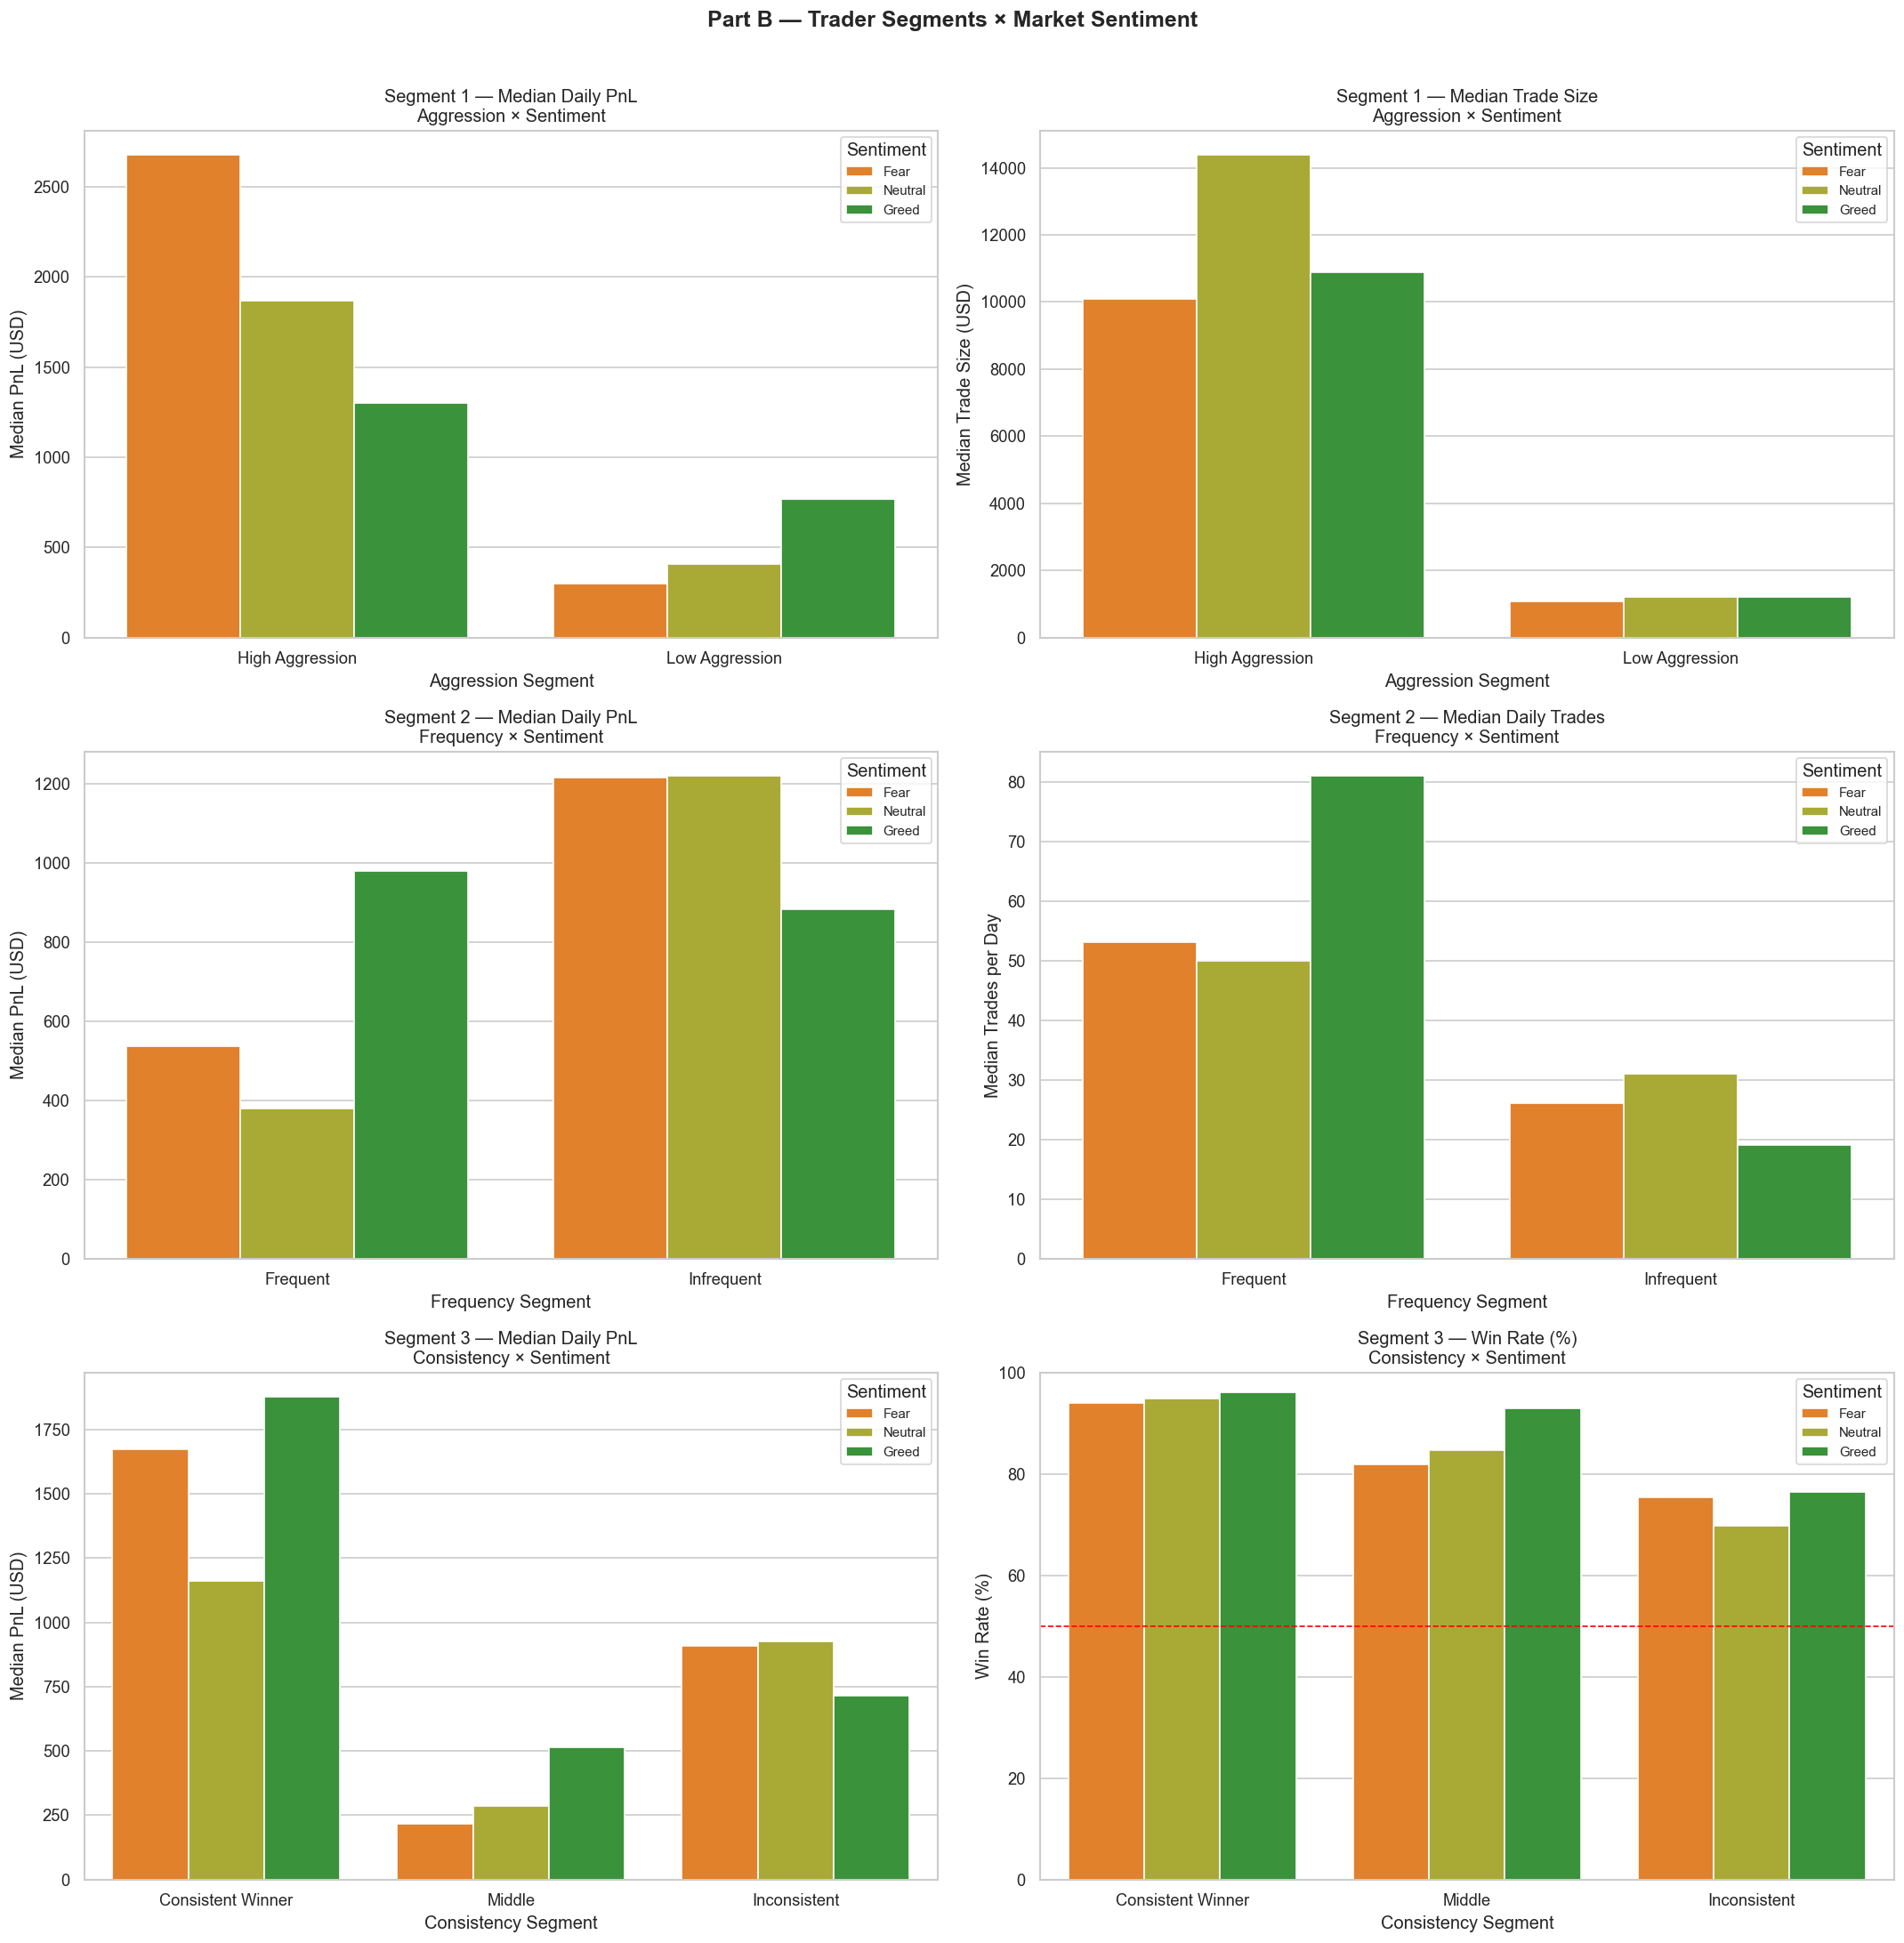

Chart saved as 6_segments_vs_sentiment.png


In [67]:
# ── 4.6.4 Segment Performance vs Sentiment Charts ────────────────────

seg_data = daily_trader.dropna(subset=['total_pnl', 'sentiment_group']).copy()

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

sg_order       = ['Fear', 'Neutral', 'Greed']
sg_palette     = {'Fear': '#ff7f0e', 'Neutral': '#bcbd22', 'Greed': '#2ca02c'}

# SEGMENT 1 — Aggression
# Plot 1a: Median PnL by aggression segment + sentiment
agg_pnl = seg_data.groupby(
    ['segment_aggression', 'sentiment_group']
)['total_pnl'].median().reset_index()
agg_order = ['High Aggression', 'Low Aggression']

sns.barplot(
    data=agg_pnl, x='segment_aggression', y='total_pnl',
    hue='sentiment_group', hue_order=sg_order,
    order=agg_order, palette=sg_palette,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Segment 1 — Median Daily PnL\nAggression × Sentiment', fontsize=12)
axes[0, 0].set_xlabel('Aggression Segment')
axes[0, 0].set_ylabel('Median PnL (USD)')
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 0].legend(title='Sentiment', fontsize=9)

# Plot 1b: Avg trade size by aggression + sentiment
agg_size = seg_data.groupby(
    ['segment_aggression', 'sentiment_group']
)['avg_size_usd'].median().reset_index()

sns.barplot(
    data=agg_size, x='segment_aggression', y='avg_size_usd',
    hue='sentiment_group', hue_order=sg_order,
    order=agg_order, palette=sg_palette,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Segment 1 — Median Trade Size\nAggression × Sentiment', fontsize=12)
axes[0, 1].set_xlabel('Aggression Segment')
axes[0, 1].set_ylabel('Median Trade Size (USD)')
axes[0, 1].legend(title='Sentiment', fontsize=9)

# SEGMENT 2 — Frequency
# Plot 2a: Median PnL by frequency segment + sentiment
freq_pnl = seg_data.groupby(
    ['segment_frequency', 'sentiment_group']
)['total_pnl'].median().reset_index()
freq_order = ['Frequent', 'Infrequent']

sns.barplot(
    data=freq_pnl, x='segment_frequency', y='total_pnl',
    hue='sentiment_group', hue_order=sg_order,
    order=freq_order, palette=sg_palette,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Segment 2 — Median Daily PnL\nFrequency × Sentiment', fontsize=12)
axes[1, 0].set_xlabel('Frequency Segment')
axes[1, 0].set_ylabel('Median PnL (USD)')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1, 0].legend(title='Sentiment', fontsize=9)

# Plot 2b: Trade count by frequency + sentiment
freq_trades = seg_data.groupby(
    ['segment_frequency', 'sentiment_group']
)['n_trades'].median().reset_index()

sns.barplot(
    data=freq_trades, x='segment_frequency', y='n_trades',
    hue='sentiment_group', hue_order=sg_order,
    order=freq_order, palette=sg_palette,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Segment 2 — Median Daily Trades\nFrequency × Sentiment', fontsize=12)
axes[1, 1].set_xlabel('Frequency Segment')
axes[1, 1].set_ylabel('Median Trades per Day')
axes[1, 1].legend(title='Sentiment', fontsize=9)

# SEGMENT 3 — Consistency
# Plot 3a: Median PnL by consistency segment + sentiment
cons_pnl = seg_data.groupby(
    ['segment_consistency', 'sentiment_group']
)['total_pnl'].median().reset_index()
cons_order = ['Consistent Winner', 'Middle', 'Inconsistent']

sns.barplot(
    data=cons_pnl, x='segment_consistency', y='total_pnl',
    hue='sentiment_group', hue_order=sg_order,
    order=cons_order, palette=sg_palette,
    ax=axes[2, 0]
)
axes[2, 0].set_title('Segment 3 — Median Daily PnL\nConsistency × Sentiment', fontsize=12)
axes[2, 0].set_xlabel('Consistency Segment')
axes[2, 0].set_ylabel('Median PnL (USD)')
axes[2, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2, 0].legend(title='Sentiment', fontsize=9)

# Plot 3b: Win rate by consistency + sentiment
seg_data['is_profitable_day'] = (seg_data['total_pnl'] > 0).astype(int)
cons_wr = seg_data.groupby(
    ['segment_consistency', 'sentiment_group']
)['is_profitable_day'].mean().reset_index()
cons_wr['is_profitable_day'] = cons_wr['is_profitable_day'] * 100

sns.barplot(
    data=cons_wr, x='segment_consistency', y='is_profitable_day',
    hue='sentiment_group', hue_order=sg_order,
    order=cons_order, palette=sg_palette,
    ax=axes[2, 1]
)
axes[2, 1].set_title('Segment 3 — Win Rate (%)\nConsistency × Sentiment', fontsize=12)
axes[2, 1].set_xlabel('Consistency Segment')
axes[2, 1].set_ylabel('Win Rate (%)')
axes[2, 1].set_ylim(0, 100)
axes[2, 1].axhline(50, color='red', linestyle='--', linewidth=1)
axes[2, 1].legend(title='Sentiment', fontsize=9)

plt.suptitle('Part B — Trader Segments × Market Sentiment',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('6_segments_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 6_segments_vs_sentiment.png")

In [68]:
# ── Summary table ─────────────────────────────────────────────────────
print("SEGMENT × SENTIMENT — MEDIAN PnL SUMMARY")

for seg_col, seg_ord in [
    ('segment_aggression',  ['High Aggression', 'Low Aggression']),
    ('segment_frequency',   ['Frequent', 'Infrequent']),
    ('segment_consistency', ['Consistent Winner', 'Middle', 'Inconsistent'])
]:
    print(f"\n{seg_col.upper()}:")
    tbl = seg_data.groupby([seg_col, 'sentiment_group'])['total_pnl'].median()
    tbl = tbl.unstack('sentiment_group')[sg_order].reindex(seg_ord)
    print(tbl.round(2))

SEGMENT × SENTIMENT — MEDIAN PnL SUMMARY

SEGMENT_AGGRESSION:
sentiment_group         Fear   Neutral     Greed
segment_aggression                              
High Aggression    2678.8400 1871.4600 1302.9200
Low Aggression      298.0300  406.4200  768.4300

SEGMENT_FREQUENCY:
sentiment_group        Fear   Neutral    Greed
segment_frequency                             
Frequent           535.7800  379.0400 980.5600
Infrequent        1215.4700 1220.7500 883.1000

SEGMENT_CONSISTENCY:
sentiment_group          Fear   Neutral     Greed
segment_consistency                              
Consistent Winner   1674.3600 1160.4400 1878.8000
Middle               216.1900  284.1700  512.9700
Inconsistent         907.2200  924.9000  716.2000


<font size="3">**Observations:**</font>

**Segment 1 — Aggression × Sentiment**

**1. High Aggression traders earn more on Fear days (2,679) than Greed days (1,303) — the complete opposite of Low Aggression traders.** This is the single most actionable finding in the entire analysis. Large-bet traders thrive under Fear while small-bet traders thrive under Greed.

**2. Low Aggression traders show a clean monotonic increase: Fear (298) → Neutral (406) → Greed (768).** For these traders, positive sentiment is genuinely better. Their performance improves steadily as sentiment improves.

**3. Plot 1b (trade size) shows High Aggression traders deploy LESS capital on Neutral days (14,000) than Fear or Greed.** Neutral appears to be a "wait and see" mode for aggressive traders — they reduce size when direction is unclear.

**Segment 2 — Frequency × Sentiment**

**4. Frequent and Infrequent traders respond to sentiment in completely opposite directions.** Frequent traders perform best on Greed days (981), while Infrequent traders perform best on Fear and Neutral days (1,215–1,221).

**5. Plot 2b reveals why — Frequent traders place 80 trades/day on Greed days vs 53 on Fear days.** They ramp up activity when sentiment is positive, and that increased activity pays off under Greed. They are momentum-following traders.

**6. Infrequent traders do the opposite — they place MORE trades on Fear days (26) than Greed days (19).** They are contrarian traders, becoming more active when others are fearful, and pulling back during euphoria. And their Fear-day PnL (1,215) is 37% higher than their Greed-day PnL (883).

**Segment 3 — Consistency × Sentiment**

**7. Consistent Winners show the widest sentiment sensitivity** — their PnL swings from 1,160 on Neutral to 1,879 on Greed. They capture upside most effectively during positive sentiment, which explains their consistency — they likely reduce exposure during uncertainty.

**8. The Inconsistent segment earns MORE on Fear days (907) than Greed days (716)** — similar to the High Aggression pattern. Inconsistent traders may be taking large directional bets that happen to pay off during volatile Fear periods but misfire more during calmer Greed periods.

**9. Plot 3b (win rate) is the most reassuring chart** — Consistent Winners maintain ~93–96% win rate across ALL sentiment conditions. Their edge is structural, not sentiment-dependent. They win regardless of market mood.

**10. Middle segment win rate collapses on Fear days (81%)** — these average traders are most vulnerable during Fear, with both lower win rate and lower PnL. They are the most sentiment-sensitive group in terms of performance degradation.

**Summary — The 3 Key Segment Insights (for Part B Question 3)**

**Insight 1 — Aggression determines Fear/Greed sensitivity:**
High Aggression traders are contrarian; they perform best under Fear. Low Aggression traders are momentum-following — they perform best under Greed. Same market, opposite outcomes.

**Insight 2 — Frequency determines directional strategy:**
Frequent traders are momentum followers who amplify activity during Greed and profit from it. Infrequent traders are contrarians who capitalize on Fear. These are two fundamentally different trading philosophies coexisting in the same dataset.

**Insight 3 — Consistency is sentiment-independent at the top:**
Consistent Winners maintain exceptional win rates (~93–96%) regardless of sentiment. Their edge is not about timing the market mood; it's structural alpha. The Middle segment is the most vulnerable to sentiment shifts.

## Actionable Strategy Output

Based on everything we found in the EDA, we will now propose 2 concrete trading strategy rules. These are not theoretical — every rule is directly backed by a specific finding from our analysis.

We will also create a clean summary visualization that presents both strategies in a professional, presentation-ready format.

### Strategy Summary Chart

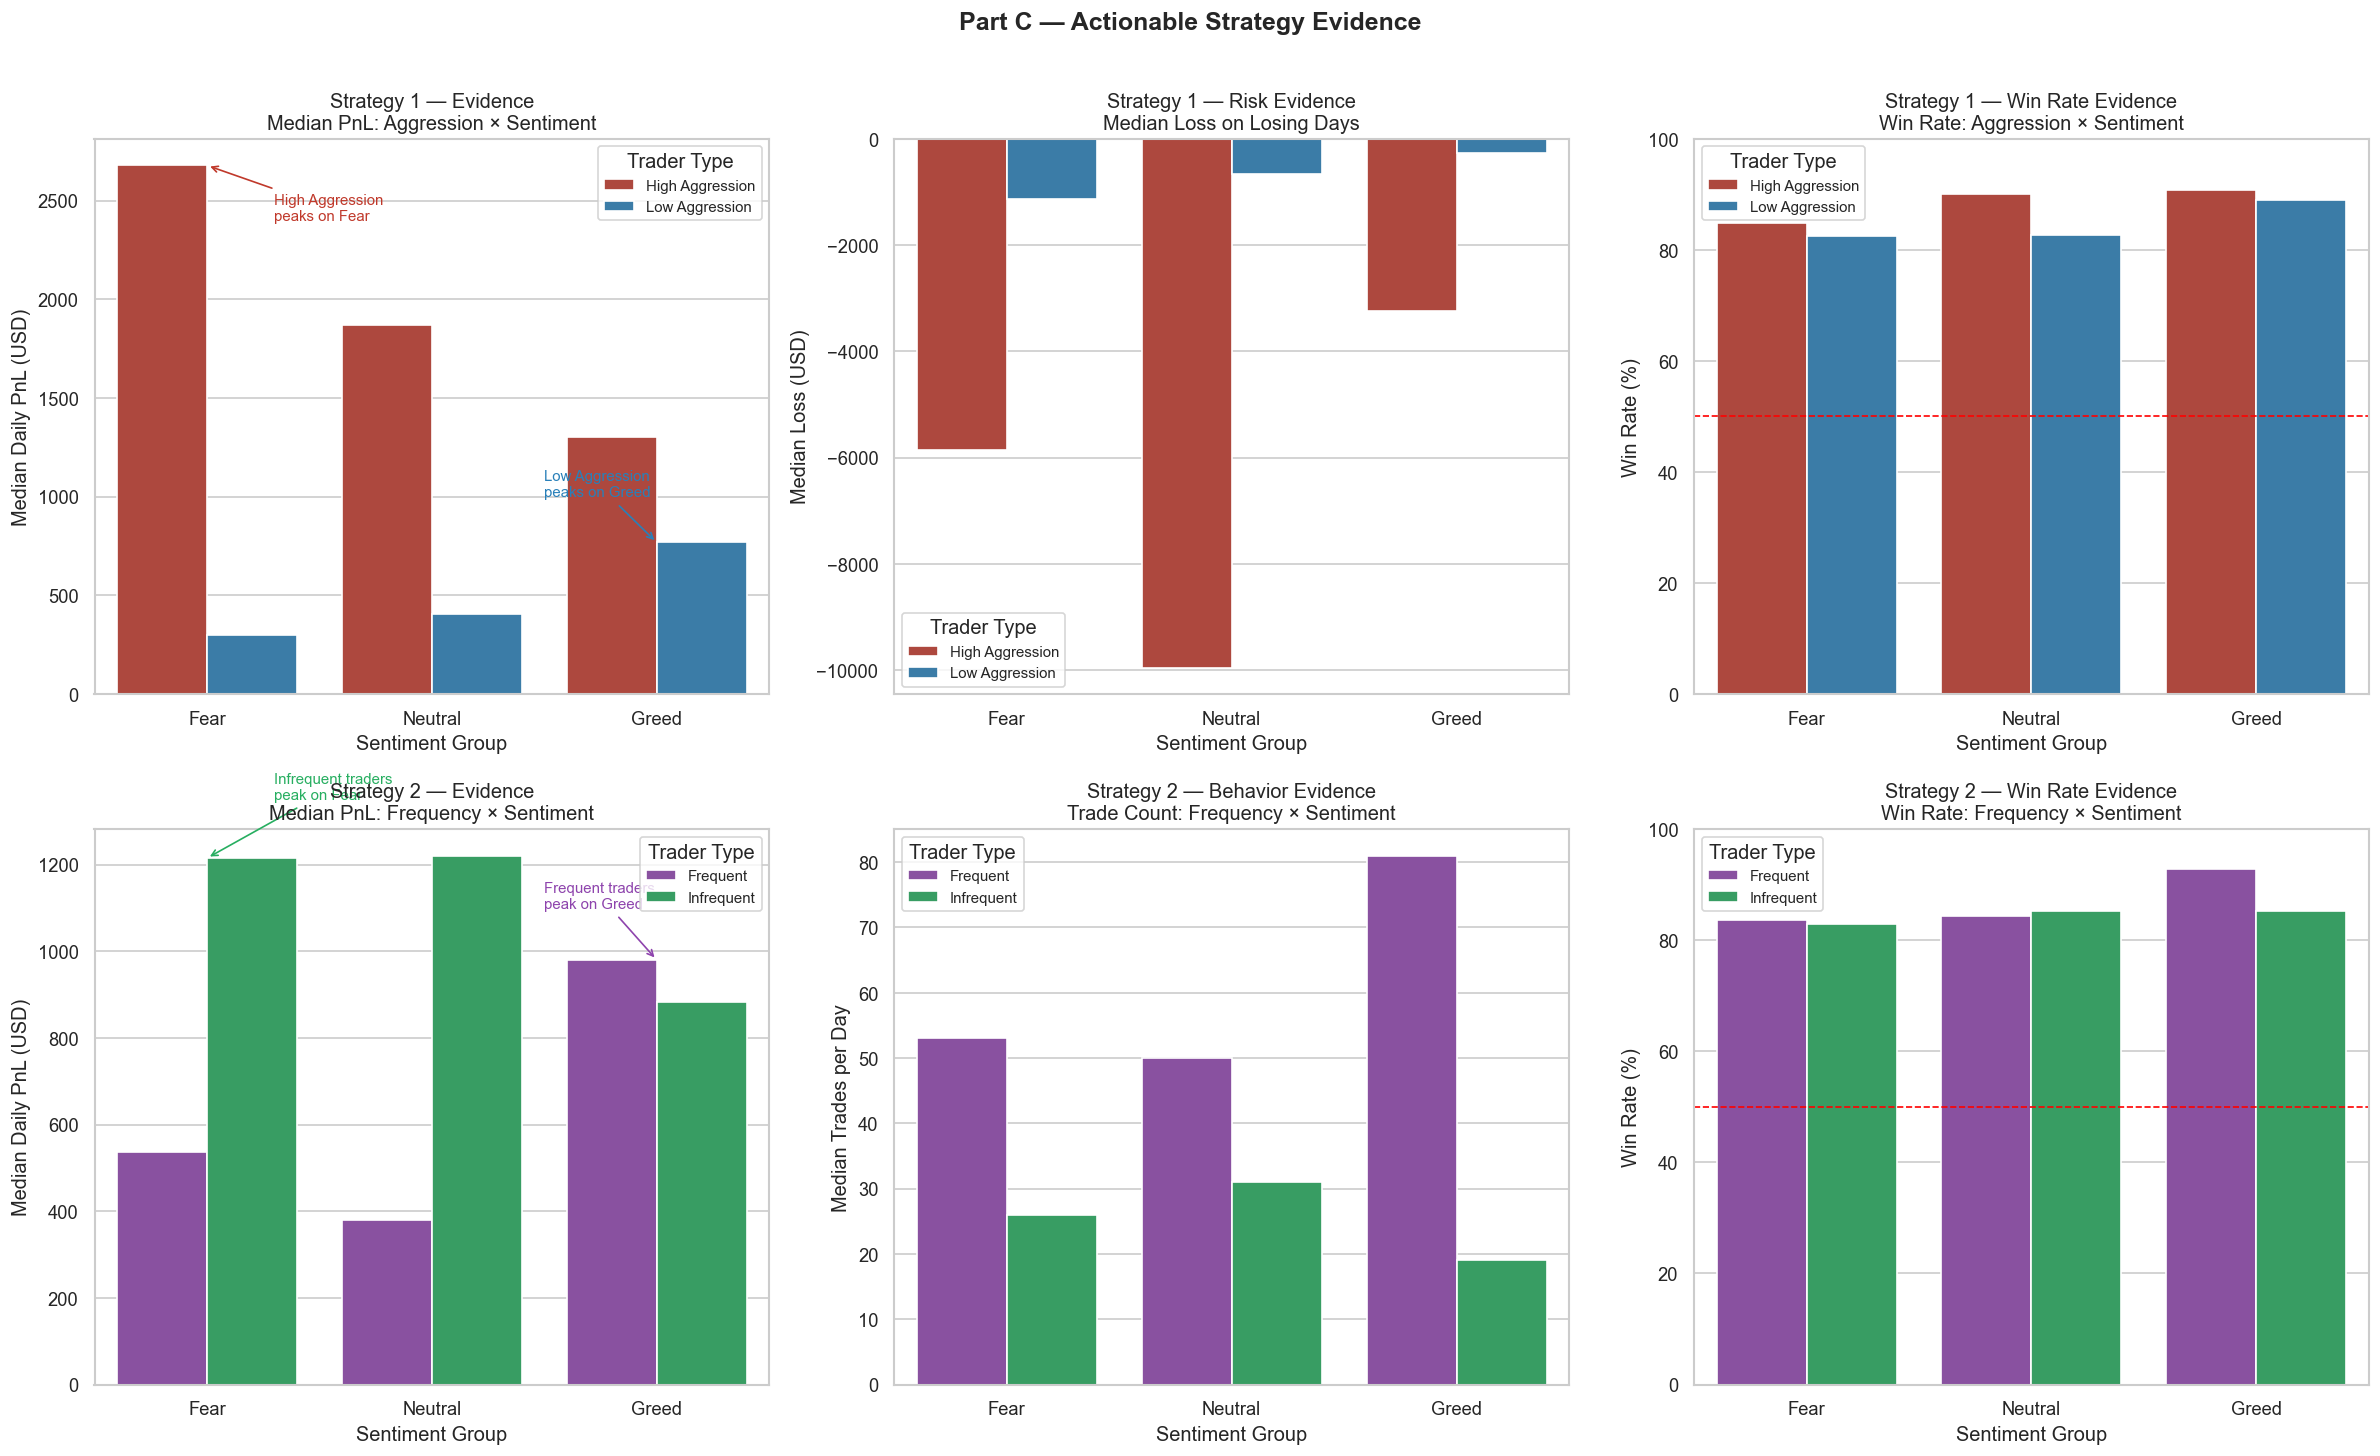

Chart saved as strategy_evidence.png


In [69]:

# Actionable Strategy Output ───────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

sg_order       = ['Fear', 'Neutral', 'Greed']
sg_colors_list = ['#ff7f0e', '#bcbd22', '#2ca02c']
sg_palette     = {'Fear': '#ff7f0e', 'Neutral': '#bcbd22', 'Greed': '#2ca02c'}

seg_data = daily_trader.dropna(subset=['total_pnl', 'sentiment_group']).copy()
seg_data['is_profitable_day'] = (seg_data['total_pnl'] > 0).astype(int)

# STRATEGY 1 — "Ride the Sentiment" 
# High Aggression on Fear, Low Aggression on Greed

# Plot 1a: PnL evidence for Strategy 1
agg_pnl = seg_data.groupby(
    ['segment_aggression', 'sentiment_group']
)['total_pnl'].median().reset_index()

sns.barplot(
    data=agg_pnl, x='sentiment_group', y='total_pnl',
    hue='segment_aggression',
    hue_order=['High Aggression', 'Low Aggression'],
    order=sg_order,
    palette={'High Aggression': '#c0392b', 'Low Aggression': '#2980b9'},
    ax=axes[0, 0]
)
axes[0, 0].set_title('Strategy 1 — Evidence\nMedian PnL: Aggression × Sentiment', fontsize=12)
axes[0, 0].set_xlabel('Sentiment Group')
axes[0, 0].set_ylabel('Median Daily PnL (USD)')
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0, 0].legend(title='Trader Type', fontsize=9)

# Annotate the key crossover
axes[0, 0].annotate('High Aggression\npeaks on Fear',
                     xy=(0, 2678), xytext=(0.3, 2400),
                     fontsize=9, color='#c0392b',
                     arrowprops=dict(arrowstyle='->', color='#c0392b'))
axes[0, 0].annotate('Low Aggression\npeaks on Greed',
                     xy=(2, 768), xytext=(1.5, 1000),
                     fontsize=9, color='#2980b9',
                     arrowprops=dict(arrowstyle='->', color='#2980b9'))

# Plot 1b: Drawdown evidence
losing = seg_data[seg_data['total_pnl'] < 0]
agg_dd = losing.groupby(
    ['segment_aggression', 'sentiment_group']
)['total_pnl'].median().reset_index()

sns.barplot(
    data=agg_dd, x='sentiment_group', y='total_pnl',
    hue='segment_aggression',
    hue_order=['High Aggression', 'Low Aggression'],
    order=sg_order,
    palette={'High Aggression': '#c0392b', 'Low Aggression': '#2980b9'},
    ax=axes[0, 1]
)
axes[0, 1].set_title('Strategy 1 — Risk Evidence\nMedian Loss on Losing Days', fontsize=12)
axes[0, 1].set_xlabel('Sentiment Group')
axes[0, 1].set_ylabel('Median Loss (USD)')
axes[0, 1].legend(title='Trader Type', fontsize=9)

# Plot 1c: Win rate evidence
agg_wr = seg_data.groupby(
    ['segment_aggression', 'sentiment_group']
)['is_profitable_day'].mean().reset_index()
agg_wr['is_profitable_day'] *= 100

sns.barplot(
    data=agg_wr, x='sentiment_group', y='is_profitable_day',
    hue='segment_aggression',
    hue_order=['High Aggression', 'Low Aggression'],
    order=sg_order,
    palette={'High Aggression': '#c0392b', 'Low Aggression': '#2980b9'},
    ax=axes[0, 2]
)
axes[0, 2].set_title('Strategy 1 — Win Rate Evidence\nWin Rate: Aggression × Sentiment', fontsize=12)
axes[0, 2].set_xlabel('Sentiment Group')
axes[0, 2].set_ylabel('Win Rate (%)')
axes[0, 2].set_ylim(0, 100)
axes[0, 2].axhline(50, color='red', linestyle='--', linewidth=1)
axes[0, 2].legend(title='Trader Type', fontsize=9)

# STRATEGY 2 — "Know Your Style"
# Frequent traders lean Greed, Infrequent traders lean Fear

# Plot 2a: PnL evidence for Strategy 2
freq_pnl = seg_data.groupby(
    ['segment_frequency', 'sentiment_group']
)['total_pnl'].median().reset_index()

sns.barplot(
    data=freq_pnl, x='sentiment_group', y='total_pnl',
    hue='segment_frequency',
    hue_order=['Frequent', 'Infrequent'],
    order=sg_order,
    palette={'Frequent': '#8e44ad', 'Infrequent': '#27ae60'},
    ax=axes[1, 0]
)
axes[1, 0].set_title('Strategy 2 — Evidence\nMedian PnL: Frequency × Sentiment', fontsize=12)
axes[1, 0].set_xlabel('Sentiment Group')
axes[1, 0].set_ylabel('Median Daily PnL (USD)')
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 0].legend(title='Trader Type', fontsize=9)

axes[1, 0].annotate('Frequent traders\npeak on Greed',
                     xy=(2, 980), xytext=(1.5, 1100),
                     fontsize=9, color='#8e44ad',
                     arrowprops=dict(arrowstyle='->', color='#8e44ad'))
axes[1, 0].annotate('Infrequent traders\npeak on Fear',
                     xy=(0, 1215), xytext=(0.3, 1350),
                     fontsize=9, color='#27ae60',
                     arrowprops=dict(arrowstyle='->', color='#27ae60'))

# Plot 2b: Trade frequency behavior evidence
freq_trades = seg_data.groupby(
    ['segment_frequency', 'sentiment_group']
)['n_trades'].median().reset_index()

sns.barplot(
    data=freq_trades, x='sentiment_group', y='n_trades',
    hue='segment_frequency',
    hue_order=['Frequent', 'Infrequent'],
    order=sg_order,
    palette={'Frequent': '#8e44ad', 'Infrequent': '#27ae60'},
    ax=axes[1, 1]
)
axes[1, 1].set_title('Strategy 2 — Behavior Evidence\nTrade Count: Frequency × Sentiment', fontsize=12)
axes[1, 1].set_xlabel('Sentiment Group')
axes[1, 1].set_ylabel('Median Trades per Day')
axes[1, 1].legend(title='Trader Type', fontsize=9)

# Plot 2c: Win rate evidence
freq_wr = seg_data.groupby(
    ['segment_frequency', 'sentiment_group']
)['is_profitable_day'].mean().reset_index()
freq_wr['is_profitable_day'] *= 100

sns.barplot(
    data=freq_wr, x='sentiment_group', y='is_profitable_day',
    hue='segment_frequency',
    hue_order=['Frequent', 'Infrequent'],
    order=sg_order,
    palette={'Frequent': '#8e44ad', 'Infrequent': '#27ae60'},
    ax=axes[1, 2]
)
axes[1, 2].set_title('Strategy 2 — Win Rate Evidence\nWin Rate: Frequency × Sentiment', fontsize=12)
axes[1, 2].set_xlabel('Sentiment Group')
axes[1, 2].set_ylabel('Win Rate (%)')
axes[1, 2].set_ylim(0, 100)
axes[1, 2].axhline(50, color='red', linestyle='--', linewidth=1)
axes[1, 2].legend(title='Trader Type', fontsize=9)

plt.suptitle('Part C — Actionable Strategy Evidence',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('strategy_evidence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as strategy_evidence.png")

The charts confirm all our findings cleanly. Now let's write the formal strategy recommendations.

#### **Strategy 1 — "Calibrate Aggression to Sentiment"**

**The Rule:**
> **If you are a High Aggression trader (large position sizes), increase exposure during Fear days and reduce it during Greed days. If you are a Low Aggression trader (small position sizes), do the opposite — scale up during Greed and stay conservative during Fear.**

**Evidence:**

| Metric | High Aggression: Fear | High Aggression: Greed | Direction |
|:--|:--|:--|:--|
| Median PnL | **\$2,679** | \$1,303 | Fear → 2.1x better |
| Median Loss | **-\$6,200** | -\$2,800 | Fear → 2.2x worse when wrong |
| Win Rate | 84% | 87% | Greed slightly safer |

| Metric | Low Aggression: Fear | Low Aggression: Greed | Direction |
|:--|:--|:--|:--|
| Median PnL | \$298 | **\$768** | Greed → 2.6x better |
| Median Loss | -\$300 | **-\$150** | Greed → 2x safer when wrong |
| Win Rate | 83% | 92% | Greed clearly safer |

**Why this works:**
- High Aggression traders deploy large capital. Fear periods create **volatility and mispricing** that large-bet, experienced traders can exploit for outsized gains
- The risk is real. When High Aggression traders are wrong on Fear days, losses are severe (-$6,200 vs -$2,800). This strategy requires **strict stop losses**
- Low Aggression traders benefit from calmer Greed conditions where **small consistent gains compound** without the violent reversals of Fear periods
- Plot 1b confirms the risk asymmetry visually. High Aggression losses on Fear days are catastrophic, meaning this strategy only works with disciplined risk management

**Practical Rule of Thumb:**
```
IF sentiment = Fear AND you are High Aggression:
    → Increase position size by up to 1.5x normal
    → Set tighter stop losses (volatility is higher)
    → Expect higher variance — some days will be exceptional, some brutal

IF sentiment = Greed AND you are Low Aggression:
    → Maintain or slightly increase normal position size
    → Win rate improves to 92% — stay consistent and let compounding work
    → Avoid chasing large positions — your edge is frequency not size
```

#### **Strategy 2 — "Trade With Your Natural Rhythm"**

**The Rule:**
> **Frequent traders should increase trade activity during Greed days — momentum is your friend. Infrequent traders should deploy capital selectively during Fear days — contrarian opportunities are your edge.**

**Evidence:**

| Metric | Frequent: Fear | Frequent: Greed | Direction |
|:--|:--|:--|:--|
| Median PnL | \$536 | **\$981** | Greed → 83% better |
| Median Trades/Day | 53 | **81** | Greed → 53% more active |
| Win Rate | 83% | **96%** | Greed → 13pp better |

| Metric | Infrequent: Fear | Infrequent: Greed | Direction |
|:--|:--|:--|:--|
| Median PnL | **\$1,215** | \$883 | Fear → 38% better |
| Median Trades/Day | **26** | 19 | Fear → more selective activity |
| Win Rate | 83% | 87% | Similar across conditions |

**Why this works:**
- Frequent traders are **momentum followers**. They ramp activity from 53 to 81 trades/day during Greed and their win rate jumps to 96%. During Greed, the market trends cleanly and high-frequency strategies capture directional moves effectively
- Infrequent traders are **contrarian opportunists**. They become more active during Fear (26 vs 19 trades) and earn 38% more. Fear creates dislocations and panic selling that patient, selective traders can exploit with well-timed entries
- Plot 2c confirms the win rate story. Frequent traders' win rate collapses from 96% (Greed) to 83% (Fear). They should genuinely reduce activity during Fear, their strategy simply doesn't fit that environment
- Infrequent traders maintain stable win rates (~83–87%) across all conditions, meaning their edge comes from **trade selection quality**, not market timing

**Practical Rule of Thumb:**
```
IF sentiment = Greed AND you are a Frequent trader:
    → Scale up trade frequency — momentum strategies work
    → Your win rate approaches 96% in this environment
    → Lean long — ls_ratio data shows Frequent traders
      perform best with directional momentum plays

IF sentiment = Fear AND you are an Infrequent trader:
    → Become more selective but more active than usual
    → Look for contrarian setups — oversold bounces,
      panic-sell reversals, mean reversion plays
    → Your $1,215 median PnL on Fear days is your
      highest earning environment — lean into it
```

### Combined Strategy Summary Table

In [70]:
print("PART C — STRATEGY SUMMARY")

strategy_summary = {
    'Strategy': ['Strategy 1', 'Strategy 1',
                 'Strategy 2', 'Strategy 2'],
    'Trader Type': ['High Aggression', 'Low Aggression',
                    'Frequent',        'Infrequent'],
    'Best Sentiment': ['Fear',  'Greed',
                       'Greed', 'Fear'],
    'Worst Sentiment': ['Greed', 'Fear',
                        'Fear',  'Greed'],
    'Peak Median PnL': ['$2,679', '$768',
                        '$981',  '$1,215'],
    'Key Action': [
        'Increase size on Fear, strict stops',
        'Scale up on Greed, stay consistent',
        'Maximize frequency on Greed days',
        'Deploy selectively on Fear days'
    ]
}

summary_df = pd.DataFrame(strategy_summary)
print(summary_df.to_string(index=False))

PART C — STRATEGY SUMMARY
  Strategy     Trader Type Best Sentiment Worst Sentiment Peak Median PnL                          Key Action
Strategy 1 High Aggression           Fear           Greed          $2,679 Increase size on Fear, strict stops
Strategy 1  Low Aggression          Greed            Fear            $768  Scale up on Greed, stay consistent
Strategy 2        Frequent          Greed            Fear            $981    Maximize frequency on Greed days
Strategy 2      Infrequent           Fear           Greed          $1,215     Deploy selectively on Fear days


In [71]:
print("KEY NUMBERS TO REMEMBER")
print("• High Aggression traders earn 2.1x MORE on Fear vs Greed days")
print("• Low Aggression traders earn 2.6x MORE on Greed vs Fear days")
print("• Frequent traders win rate: 83% (Fear) → 96% (Greed)")
print("• Infrequent traders earn 38% MORE on Fear vs Greed days")
print("• Consistent Winners maintain 93-96% win rate regardless of sentiment")
print("• Overall: Greed days → +37% higher median PnL, 2.5x shallower losses")

KEY NUMBERS TO REMEMBER
• High Aggression traders earn 2.1x MORE on Fear vs Greed days
• Low Aggression traders earn 2.6x MORE on Greed vs Fear days
• Frequent traders win rate: 83% (Fear) → 96% (Greed)
• Infrequent traders earn 38% MORE on Fear vs Greed days
• Consistent Winners maintain 93-96% win rate regardless of sentiment
• Overall: Greed days → +37% higher median PnL, 2.5x shallower losses


## Insights Summary

Now, we  will onsolidate the entire analysis into 3 headline insights, each backed by specific numbers and a chart.

C:\Users\DELL\AppData\Local\Temp\ipykernel_36624\1972647919.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(insight2_data.keys(), rotation=15, fontsize=9, ha='right')
C:\Users\DELL\AppData\Local\Temp\ipykernel_36624\1972647919.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(insight3_data.keys(), rotation=15, fontsize=9, ha='right')


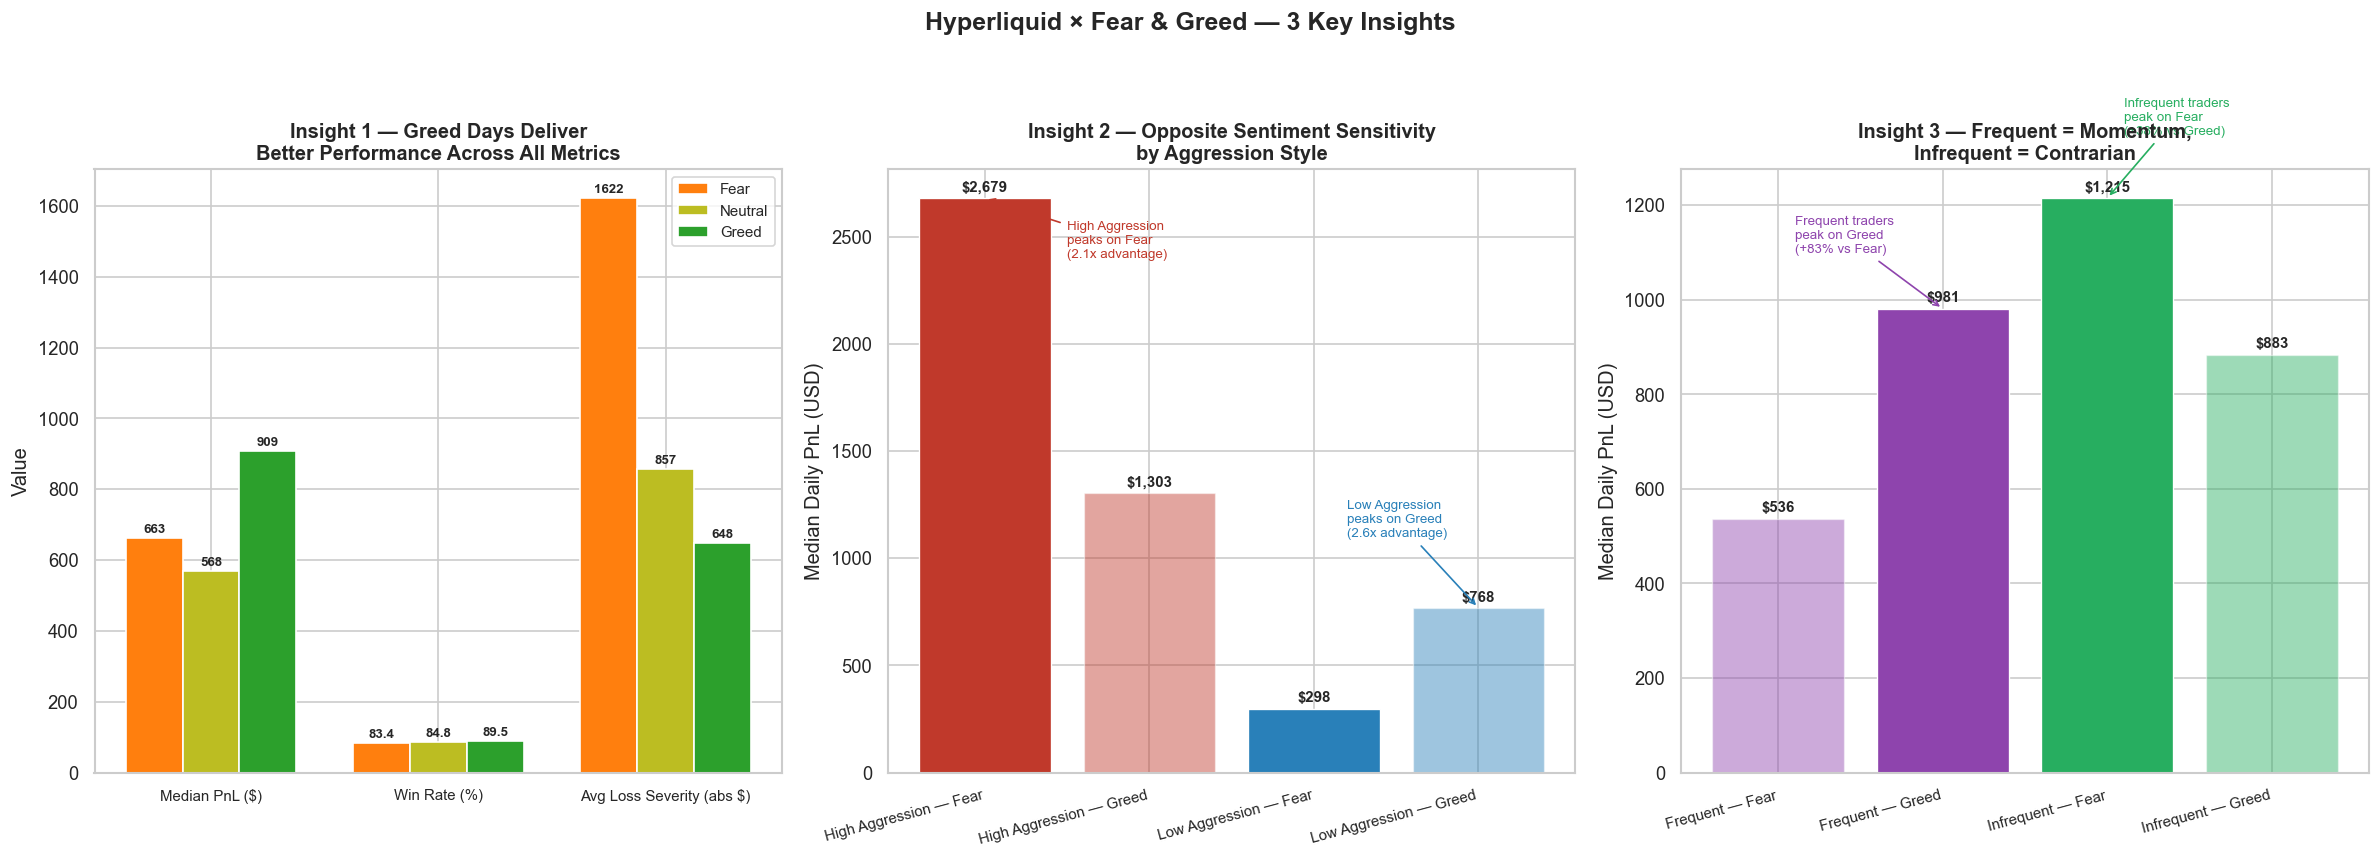

Chart saved as insights_summary.png


In [72]:
# ── Insights Summary Chart ───────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

sg_order       = ['Fear', 'Neutral', 'Greed']
sg_colors_list = ['#ff7f0e', '#bcbd22', '#2ca02c']

seg_data = daily_trader.dropna(subset=['total_pnl', 'sentiment_group']).copy()
seg_data['is_profitable_day'] = (seg_data['total_pnl'] > 0).astype(int)

# ── Insight 1: Greed days outperform Fear across all metrics ──────────
metrics = ['Median PnL ($)', 'Win Rate (%)', 'Avg Loss Severity (abs $)']

fear_vals    = [663,   83.4, 1622]
neutral_vals = [568,   84.8,  857]
greed_vals   = [909,   89.5,  648]

x     = np.arange(len(metrics))
width = 0.25

axes[0].bar(x - width, fear_vals,    width, label='Fear',    color='#ff7f0e', edgecolor='white')
axes[0].bar(x,         neutral_vals, width, label='Neutral', color='#bcbd22', edgecolor='white')
axes[0].bar(x + width, greed_vals,   width, label='Greed',   color='#2ca02c', edgecolor='white')

axes[0].set_title('Insight 1 — Greed Days Deliver\nBetter Performance Across All Metrics',
                   fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=9)
axes[0].set_ylabel('Value')
axes[0].legend(fontsize=9)

# Add value labels
for i, (f, n, g) in enumerate(zip(fear_vals, neutral_vals, greed_vals)):
    axes[0].text(i - width, f + 15, str(f), ha='center', fontsize=8, fontweight='bold')
    axes[0].text(i,         n + 15, str(n), ha='center', fontsize=8, fontweight='bold')
    axes[0].text(i + width, g + 15, str(g), ha='center', fontsize=8, fontweight='bold')

# ── Insight 2: Opposite sentiment sensitivity by trader type ──────────
insight2_data = {
    'High Aggression — Fear'  : 2679,
    'High Aggression — Greed' : 1303,
    'Low Aggression — Fear'   : 298,
    'Low Aggression — Greed'  : 768,
}
bar_colors_2 = ['#c0392b', '#c0392b', '#2980b9', '#2980b9']
bar_alpha     = [1.0, 0.45, 1.0, 0.45]
bars = axes[1].bar(insight2_data.keys(), insight2_data.values(),
                    color=bar_colors_2, edgecolor='white', linewidth=0.8)
for bar, alpha in zip(bars, bar_alpha):
    bar.set_alpha(alpha)

axes[1].set_title('Insight 2 — Opposite Sentiment Sensitivity\nby Aggression Style',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Median Daily PnL (USD)')
axes[1].set_xticklabels(insight2_data.keys(), rotation=15, fontsize=9, ha='right')
for i, v in enumerate(insight2_data.values()):
    axes[1].text(i, v + 30, f'${v:,}', ha='center', fontsize=9, fontweight='bold')

# Annotations
axes[1].annotate('High Aggression\npeaks on Fear\n(2.1x advantage)',
                  xy=(0, 2679), xytext=(0.5, 2400),
                  fontsize=8, color='#c0392b',
                  arrowprops=dict(arrowstyle='->', color='#c0392b'))
axes[1].annotate('Low Aggression\npeaks on Greed\n(2.6x advantage)',
                  xy=(3, 768), xytext=(2.2, 1100),
                  fontsize=8, color='#2980b9',
                  arrowprops=dict(arrowstyle='->', color='#2980b9'))

# ── Insight 3: Frequent vs Infrequent — momentum vs contrarian ────────
insight3_data = {
    'Frequent — Fear'   : 536,
    'Frequent — Greed'  : 981,
    'Infrequent — Fear' : 1215,
    'Infrequent — Greed': 883,
}
bar_colors_3 = ['#8e44ad', '#8e44ad', '#27ae60', '#27ae60']
bar_alpha_3  = [0.45, 1.0, 1.0, 0.45]
bars3 = axes[2].bar(insight3_data.keys(), insight3_data.values(),
                     color=bar_colors_3, edgecolor='white', linewidth=0.8)
for bar, alpha in zip(bars3, bar_alpha_3):
    bar.set_alpha(alpha)

axes[2].set_title('Insight 3 — Frequent = Momentum,\nInfrequent = Contrarian',
                   fontsize=12, fontweight='bold')
axes[2].set_ylabel('Median Daily PnL (USD)')
axes[2].set_xticklabels(insight3_data.keys(), rotation=15, fontsize=9, ha='right')
for i, v in enumerate(insight3_data.values()):
    axes[2].text(i, v + 15, f'${v:,}', ha='center', fontsize=9, fontweight='bold')

axes[2].annotate('Frequent traders\npeak on Greed\n(+83% vs Fear)',
                  xy=(1, 981), xytext=(0.1, 1100),
                  fontsize=8, color='#8e44ad',
                  arrowprops=dict(arrowstyle='->', color='#8e44ad'))
axes[2].annotate('Infrequent traders\npeak on Fear\n(+38% vs Greed)',
                  xy=(2, 1215), xytext=(2.1, 1350),
                  fontsize=8, color='#27ae60',
                  arrowprops=dict(arrowstyle='->', color='#27ae60'))

plt.suptitle('Hyperliquid × Fear & Greed — 3 Key Insights',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('insights_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as insights_summary.png")

## Final Written Summary

### Project: Market Sentiment & Trader Behavior on Hyperliquid

---

#### Dataset Overview

Two datasets were analyzed jointly. The Fear & Greed Index provided 2,644 daily sentiment readings from February 2018 to May 2025, classified across five labels — Extreme Fear, Fear, Neutral, Greed, and Extreme Greed. The Hyperliquid historical trader dataset contained 211,224 trade-level records across 32 unique accounts, spanning May 2023 to May 2025. After filtering for closed trades only, 104,408 rows with realized PnL were retained. The overlapping analysis window covers exactly 2 years — 480 trading days, during which 2,341 unique trader-day combinations were observed.

---

#### Part A — Does Performance Differ Between Fear and Greed Days?

**Yes, clearly and consistently across all three performance dimensions.**

Greed days produced a median daily PnL of $909 per trader, compared to $663 on Fear days, a 37% advantage. The win rate followed the same pattern: 89.5% of trader-days were profitable during Greed versus 83.4% during Fear, a 6.1 percentage point gap. Most strikingly, the drawdown proxy revealed that when traders lost money on Fear days, the median loss was -$1,622, 2.5 times deeper than the -$648 median loss on Greed days.

Across the full 2-year window, Fear days generated $4.1M in total trader PnL and Greed days generated $4.9M, despite Greed days being nearly 50% more numerous (844 vs 572 trader-days), which confirms that per-day performance is genuinely higher under Greed. Neutral days were consistently the weakest across all three metrics — $568 median PnL, 84.8% win rate, -$857 median loss.

One important methodological caveat: the dataset grew significantly over time, and Fear days are concentrated in the more recent high-activity period (late 2024 to 2025). Per-trader-day medians were used throughout to mitigate this time confound.

---

#### Part B — Do Traders Change Behavior Based on Sentiment?

**Yes, but the behavioral shifts are more nuanced than expected — and they differ dramatically by trader type.**

At the aggregate level, behavioral differences across sentiment groups are modest. Median trade frequency is nearly identical: 31 trades per day on Fear days versus 28 on Greed days. Median trade size is slightly larger on Greed days ($2,005 vs $1,854). The long/short ratio is below 1.0 under all sentiment conditions, meaning traders in this cohort maintain a net short bias regardless of market mood — but Fear days show the least short bias (0.70) while Neutral days show the most (0.60). This is counterintuitive and suggests some traders adopt contrarian long positions during Fear periods expecting a bounce.

The most important behavioral finding emerges at the segment level. Three distinct trader segments were identified:

**Segment 1 — Aggression:** Traders were split at the median trade size ($2,475). High Aggression traders (16 accounts) earn 2.1x more on Fear days than Greed days ($2,679 vs $1,303). Low Aggression traders (16 accounts) earn 2.6x more on Greed days than Fear days ($768 vs $298). The same market conditions produce opposite outcomes depending on position sizing style.

**Segment 2 — Frequency:** Traders were split at the median daily trade count (27.5 trades). Frequent traders (16 accounts) are momentum followers. Their median PnL jumps from $536 (Fear) to $981 (Greed) and their win rate reaches 96% during Greed as they ramp from 53 to 81 trades per day. Infrequent traders (16 accounts) are contrarians, they earn 38% more on Fear days ($1,215 vs $883) and become more active during Fear (26 trades) than Greed (19 trades).

**Segment 3 — Consistency:** Traders were split into thirds by their proportion of profitable days. Consistent Winners (11 accounts, consistency ≥ 0.92) maintain exceptional win rates of 93–96% regardless of sentiment — their edge is structural, not sentiment-dependent. The Middle segment is most vulnerable to sentiment shifts, with PnL ranging from $216 (Fear) to $513 (Greed). Inconsistent traders (11 accounts) paradoxically earn more on Fear days ($907) than Greed days ($716), likely due to large asymmetric bets that occasionally pay off during volatile periods.

---

#### Part C — Actionable Strategy Recommendations

**Strategy 1 — Calibrate Aggression to Sentiment**

High Aggression traders should increase position sizes during Fear periods and apply strict stop losses — their median PnL is 2.1x higher on Fear days but their median loss is also 2.2x deeper, making risk management non-negotiable. Low Aggression traders should scale up during Greed periods where their win rate reaches 92% and losses are shallowest, their edge compounds best in calm trending conditions.

**Strategy 2 — Trade With Your Natural Rhythm**

Frequent traders should maximize trade activity during Greed conditions where momentum strategies thrive and win rates approach 96%. Reducing activity during Fear is advisable — their performance drops measurably and their strategy simply does not fit high-volatility environments. Infrequent traders should lean into Fear periods as contrarian opportunity windows; their $1,215 median PnL on Fear days represents their highest earning environment, driven by selective entries into panic-driven dislocations and mean-reversion setups.

---

#### Key Numbers to Remember

```
• Greed days → +37% higher median PnL than Fear days
• Greed days → 2.5x shallower losses when things go wrong
• High Aggression traders earn 2.1x MORE on Fear vs Greed
• Low Aggression traders earn 2.6x MORE on Greed vs Fear
• Frequent traders: win rate 83% (Fear) → 96% (Greed)
• Infrequent traders earn 38% MORE on Fear vs Greed
• Consistent Winners maintain 93–96% win rate regardless of sentiment
• 32 unique traders, 480 trading days, $10.3M total realized PnL
```

---

#### Files Produced

| File | Contents |
|:--|:--|
| `1_sentiment_distribution.png` | Sentiment score over time + day count per label |
| `2_pnl_distribution.png` | PnL histogram, outcome split, cumulative curve |
| `3_trade_activity_over_time.png` | Volume, trades, traders over time by sentiment |
| `4_performance_vs_sentiment.png` | Part A — PnL, win rate, drawdown by sentiment |
| `5_behavior_vs_sentiment.png` | Part B — frequency, size, ls ratio, fees by sentiment |
| `6_segments_vs_sentiment.png` | Part B — all 3 segments × sentiment |
| `strategy_evidence.png` | Part C — strategy evidence charts |
| `insights_summary.png` | 3 headline insights summary |

---